<a href="https://colab.research.google.com/github/aedenj/faithful-cuts/blob/main/CSED504_Faithful_Cuts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, sys

_REPO_DIR = os.path.abspath("faithful-cuts")

if not os.path.isdir(_REPO_DIR):
    !git clone https://github.com/aedenj/faithful-cuts.git

if _REPO_DIR not in sys.path:
    sys.path.insert(0, _REPO_DIR)


Cloning into 'faithful-cuts'...
remote: Enumerating objects: 160, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 160 (delta 86), reused 76 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (160/160), 3.23 MiB | 6.63 MiB/s, done.
Resolving deltas: 100% (86/86), done.


In [2]:
!pip install -q -U qwen-omni-utils outlines pydantic networkx openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.3 MB/s eta 0:00:00


# Setup

In [3]:
import requests
import gc
import json
import re
from pathlib import Path

from pydantic import BaseModel, Field, ConfigDict

import outlines
from outlines.inputs import Chat, Video

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.video_utils import load_video
import numpy as np

import pandas as pd
from moviepy.video.io.VideoFileClip import VideoFileClip

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)


In [4]:
def cleanup_gpu():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

### Download Data

In [5]:
BBC_ROOT = Path("bbc").resolve()
BBC_FOLDER_ID = "1SbqWxfZ6YHBNAIFwtraJZXl1K3qNq3M_"

EXP_RUNS_PATH = BBC_ROOT / "runs"
CURRENT_EXP_FOLDER = "qwen35-gpt4o"

SCENE_CACHE_PATH = Path('/content/bbc/runs') / CURRENT_EXP_FOLDER / 'scene_descriptions.csv'
FACTS_CACHE_PATH = Path('/content/bbc/runs') / CURRENT_EXP_FOLDER / 'scene_facts.csv'
QUESTIONS_CACHE_PATH = Path('/content/bbc/runs') / CURRENT_EXP_FOLDER / 'scene_questions.csv'
GRAPH_CACHE_PATH = Path('/content/bbc/runs') / CURRENT_EXP_FOLDER / 'scene_dependencies.csv'

In [6]:
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

auth.authenticate_user()
_drive = build("drive", "v3")

def _list_children(folder_id):
    items, page_token = [], None
    while True:
        resp = (
            _drive.files()
            .list(
                q=f"'{folder_id}' in parents and trashed=false",
                fields="nextPageToken, files(id, name, mimeType)",
                pageSize=1000,
                pageToken=page_token,
                supportsAllDrives=True,
                includeItemsFromAllDrives=True,
            )
            .execute()
        )
        items.extend(resp.get("files", []))
        page_token = resp.get("nextPageToken")
        if not page_token:
            return items

def _download_bbc_tree(folder_id, dest):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    for item in _list_children(folder_id):
        # Skip anything that isn't part of the BBC dataset (e.g. models/).
        if item["mimeType"] == "application/vnd.google-apps.folder" and item["name"] == "models":
            continue

        target = dest / item["name"]
        if item["mimeType"] == "application/vnd.google-apps.folder":
            _download_bbc_tree(item["id"], target)
        elif not target.exists():
            request = _drive.files().get_media(fileId=item["id"], supportsAllDrives=True)
            with open(target, "wb") as fh:
                downloader = MediaIoBaseDownload(fh, request, chunksize=64 * 1024 * 1024)
                done = False
                while not done:
                    _, done = downloader.next_chunk()
            print(f"  {target.relative_to(BBC_ROOT)}")

#### Download Runs

Downloads all previous experiments with this notebook.

In [7]:
runs_folder_id = None
for item in _list_children(BBC_FOLDER_ID):
    if item["name"] == "runs" and item["mimeType"] == "application/vnd.google-apps.folder":
        runs_folder_id = item["id"]
        break

if runs_folder_id:
    print(f"Downloading experiment runs to {EXP_RUNS_PATH} (Drive API)...")
    _download_bbc_tree(runs_folder_id, EXP_RUNS_PATH)
    print("Experiment runs download complete.")
else:
    print(f"Could not find 'runs' folder within BBC_FOLDER_ID: {BBC_FOLDER_ID}")

  runs/qwen35-gpt4o/injection_pipelines.csv
  runs/qwen35-gpt4o/injection_variants.csv
  runs/qwen35-gpt4o/scene_questions.csv
  runs/qwen35-gpt4o/scene_dependencies.csv
  runs/qwen35-gpt4o/scene_facts.csv
  runs/qwen35-gpt4o/scene_descriptions.csv
Experiment runs download complete.


#### Download BBC Dataset - MP4's & Ground Truth

This can be skipped if ya don't need it, which is the case when working with a specific experiment run

In [ ]:
bbc_movies = [f"bbc_{n:02d}" for n in range(1, 12)]

def _bbc_assets_present():
    gt_ok = all(
        (BBC_ROOT / "GT" / f"{m}_shots.csv").exists()
        and (BBC_ROOT / "GT" / f"{m}_scenes.csv").exists()  # Corrected line
        for m in bbc_movies
    )
    videos_ok = all((BBC_ROOT / f"{m}.mp4").exists() for m in bbc_movies)
    return gt_ok and videos_ok


if not _bbc_assets_present():
    print(f"Downloading BBC dataset (GT and MP4s) to {BBC_ROOT} (Drive API)...")

    # List all children of the main BBC folder
    bbc_items = _list_children(BBC_FOLDER_ID)

    gt_folder_id = None
    mp4_files_to_download = []

    for item in bbc_items:
        if item["name"] == "GT" and item["mimeType"] == "application/vnd.google-apps.folder":
            gt_folder_id = item["id"]
        elif item["name"].endswith(".mp4") and item["name"].startswith("bbc_"):
            mp4_files_to_download.append(item)

    # Download the GT folder
    if gt_folder_id:
        print(f"  Downloading GT folder...")
        _download_bbc_tree(gt_folder_id, BBC_ROOT / "GT")
    else:
        print("  GT folder not found within BBC_FOLDER_ID.")

    # Download individual MP4 files
    for mp4_file in mp4_files_to_download:
        target_path = BBC_ROOT / mp4_file["name"]
        if not target_path.exists():
            print(f"  Downloading {mp4_file['name']}...")
            request = _drive.files().get_media(fileId=mp4_file["id"], supportsAllDrives=True)
            with open(target_path, "wb") as fh:
                downloader = MediaIoBaseDownload(fh, request, chunksize=64 * 1024 * 1024)
                done = False
                while not done:
                    _, done = downloader.next_chunk()
            print(f"    {target_path.relative_to(BBC_ROOT)}")
        else:
            print(f"  {mp4_file['name']} already exists, skipping.")

    print("BBC dataset download (GT and MP4s) complete.")

print("BBC_ROOT =", BBC_ROOT, "| assets present:", _bbc_assets_present())

  GT/bbc_02_shots.csv
  GT/bbc_01_shots.csv.xlsx
  GT/bbc_10_shots.csv
  GT/bbc_08_shots.csv
  GT/bbc_11_scenes.csv
  GT/bbc_04_shots.csv
  GT/bbc_07_shots.csv
  GT/bbc_07_scenes.csv
  GT/bbc_01_shots.xlsx
  GT/bbc_06_scenes.csv
  GT/bbc_02_scenes.csv
  GT/bbc_03_scenes.csv
  GT/bbc_videos.csv
  GT/bbc_01_shots.csv
  GT/bbc_03_shots.csv
  GT/bbc_04_scenes.csv
  GT/bbc_09_shots.csv
  GT/bbc_10_scenes.csv
  GT/bbc_11_shots.csv
  GT/bbc_06_shots.csv
  GT/bbc_05_scenes.csv
  GT/bbc_09_scenes.csv
  GT/bbc_05_shots.csv
  GT/bbc_08_scenes.csv
  GT/bbc_01_scenes.csv
    bbc_11.mp4
    bbc_10.mp4
    bbc_06.mp4
    bbc_09.mp4
    bbc_04.mp4
    bbc_07.mp4
    bbc_05.mp4
    bbc_08.mp4
    bbc_03.mp4
    bbc_02.mp4
    bbc_01.mp4
BBC dataset download (GT and MP4s) complete.
BBC_ROOT = /content/bbc | assets present: True


# Extract Scenes

The BBC videos and GT (shots/scenes CSVs) are downloaded from a shared Google Drive folder.

In [ ]:
def extract_scenes_from_gt(movie_name, root_path):
    # Load ground truth files
    shots_df = pd.read_csv(root_path / "GT" / f"{movie_name}_shots.csv")
    scenes_df = pd.read_csv(root_path / "GT" / f"{movie_name}_scenes.csv")

    def get_col(df, possible_names):
        for name in possible_names:
            if name in df.columns: return name
        raise KeyError(f"None of {possible_names} found in {df.columns.tolist()}")

    shot_start_col = get_col(shots_df, ['begin', 'start_frame', 'start'])
    shot_end_col = get_col(shots_df, ['end', 'end_frame'])
    scene_start_col = get_col(scenes_df, ['start_shot', 'begin', 'start'])
    scene_end_col = get_col(scenes_df, ['end_shot', 'end'])

    video_path = root_path / f"{movie_name}.mp4"
    output_dir = root_path / "scenes" / movie_name
    output_dir.mkdir(parents=True, exist_ok=True)

    num_shots = len(shots_df)

    with VideoFileClip(str(video_path)) as video:
        fps = video.fps

        for idx, row in scenes_df.iterrows():
            try:
                # Adjusting for 1-based indexing in the CSV
                start_shot_idx = int(row[scene_start_col]) - 1
                end_shot_idx = int(row[scene_end_col]) - 1

                # Bounds check
                if start_shot_idx < 0 or start_shot_idx >= num_shots or \
                   end_shot_idx < 0 or end_shot_idx >= num_shots:
                    print(f"  Skipping scene {idx} in {movie_name}: indices {start_shot_idx+1}-{end_shot_idx+1} out of range (total shots: {num_shots})")
                    continue

                scene_start_frame = shots_df.iloc[start_shot_idx][shot_start_col]
                scene_end_frame = shots_df.iloc[end_shot_idx][shot_end_col]

                start_time = float(scene_start_frame) / fps
                end_time = float(scene_end_frame) / fps

                output_filename = output_dir / f"scene_{idx:03d}.mp4"
                scene_clip = video.subclip(start_time, end_time)
                scene_clip.write_videofile(str(output_filename), codec="libx264", audio_codec="aac", verbose=False, logger=None)
            except Exception as inner_e:
                print(f"  Error processing scene {idx} in {movie_name}: {inner_e}")

    print(f"Finished processing {movie_name}")

# Process all BBC movies
for movie in bbc_movies:
    try:
        extract_scenes_from_gt(movie, BBC_ROOT)
    except Exception as e:
        print(f"Could not process {movie}: {e}")

NameError: name 'bbc_movies' is not defined

# Generate Scene Descriptions

### Model Setup

In [ ]:
from transformers import (
    AutoModelForMultimodalLM,
    AutoProcessor,
)

# SCENE_DESC_MODEL = "Qwen/Qwen3-VL-30B-A3B-Instruct"
SCENE_DESC_MODEL = "Qwen/Qwen3.5-35B-A3B"
# SCENE_DESC_MODEL = "Qwen/Qwen3-VL-8B-Instruct"

qwen_scene_desc_processor = AutoProcessor.from_pretrained(
    SCENE_DESC_MODEL
)

qwen_scene_desc_model = AutoModelForMultimodalLM.from_pretrained(
    SCENE_DESC_MODEL,
    device_map="auto",
    dtype="auto",
)

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/3.54k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/1026 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

In [8]:
class SceneDescription(BaseModel):
    model_config = ConfigDict(extra="forbid")

    summary: str = Field(..., description="A concise but detailed summary of the visual scene depicted in the image or video.")

In [9]:
import pandas as pd
import numpy as np

def process_all_scenes(root_path, outlines_model, processor, limit_per_movie=None):
    """
    Processes video scenes using a pre-initialized outlines model.
    Returns a pandas DataFrame of results.
    """
    all_records = []
    scene_base = root_path / "scenes"

    # Get all movie folders in the scenes directory
    movie_dirs = sorted([d for d in scene_base.iterdir() if d.is_dir()])

    for movie_dir in movie_dirs:
        movie_name = movie_dir.name
        print(f"Processing movie: {movie_name}")

        # Get all scene mp4 files
        scene_files = sorted(list(movie_dir.glob("*.mp4")))
        if limit_per_movie:
            scene_files = scene_files[:limit_per_movie]

        for scene_path in scene_files:
            try:
                # Load and sample 64 frames
                frames, metadata = load_video(
                    str(scene_path),
                    sample_indices_fn=lambda metadata, **kw: np.linspace(
                        0, metadata.total_num_frames - 1, 64
                    ).round().astype(int),
                )

                vp = processor.video_processor
                vp.do_sample_frames = False
                vp.video_metadata = [metadata]

                prompt = [
                  {
                      "role": "system",
                      "content": "You are a precise video understanding system. Report only information directly supported by the provided video.",
                  },
                  {
                      "role": "user",
                      "content": [
                          {"type": "video", "video": Video(frames)},
                          {
                              "type": "text",
                              "text": "Describe what occurs in the scene based only on visually observable evidence. Describe people, objects, actions, and settings. Do not infer or guess identities.",
                            },
                        ],
                    }
                ]

                formatted_prompt = processor.tokenizer.apply_chat_template(
                    prompt,
                    tokenize=False,
                    add_generation_prompt=True,
                    enable_thinking=False,
                )

                # Use the pre-initialized model passed into the function
                raw_result = outlines_model(
                    [formatted_prompt, Video(frames)],
                    output_type=SceneDescription,
                    max_new_tokens=1024,
                    temperature=0.2,
                )

                summary = SceneDescription.model_validate_json(raw_result).summary

                all_records.append({
                    "video_id": movie_name,
                    "scene_id": scene_path.name,
                    "description": summary
                })

                print(f"  Done: {scene_path.name}")

                del frames

            except Exception as e:
                print(f"  Error on {scene_path.name}: {e}")

    return pd.DataFrame(all_records)

In [10]:
scene_desc_model = None

if SCENE_CACHE_PATH.exists():
    df_results = pd.read_csv(SCENE_CACHE_PATH)
    print(f"Loaded {len(df_results)} cached scene descriptions from {SCENE_CACHE_PATH}")
else:
    scene_desc_model = outlines.from_transformers(qwen_scene_desc_model, qwen_scene_desc_processor)
    df_results = process_all_scenes(BBC_ROOT, scene_desc_model, qwen_scene_desc_processor)
    SCENE_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_results.to_csv(SCENE_CACHE_PATH, index=False)
    print(f"Results successfully cached to: {SCENE_CACHE_PATH}")

Loaded 670 cached scene descriptions from /content/bbc/runs/qwen35-gpt4o/scene_descriptions.csv


In [11]:
display(df_results.head())

,video_id,scene_id,description
0,bbc_01,scene_000.mp4,"The video begins with a black screen, which tr..."
1,bbc_01,scene_001.mp4,The camera pans over a mountain range with clo...
2,bbc_01,scene_002.mp4,A group of penguins are standing on an iceberg...
3,bbc_01,scene_003.mp4,A group of penguins are standing in a line on ...
4,bbc_01,scene_004.mp4,"The sun is rising over a mountain range, with ..."


In [ ]:
if scene_desc_model is not None:
    del scene_desc_model

del qwen_scene_desc_processor
del qwen_scene_desc_model

cleanup_gpu()

# FIFA Metadata Extraction

Here we re-use the DSG (Davidsonian Scene Graph) / TIFA160 annotation taxonomy and decompose a description into atomic "facts" and builds its Spatio-Temporal Semantic Dependency Graph. (Cho et al., ICLR 2024, "Davidsonian Scene Graph: Improving Reliability in
  Fine-grained Evaluation for Text-to-Image Generation")


In [13]:
import utils_video2text as fifa

from parse import (
    parse_tuples,
    parse_questions,
    parse_dependencies,
    validate_dsg,
)


### Model Setup


In [14]:
from llm import BaseLLM, GLM47FlashLLM, Qwen3LLM, OpenaiLLM


In [15]:
# extractor_llm = Qwen3LLM("Qwen/Qwen3-32B")

os.environ["OPENAI_API_KEY"] = ""
extractor_llm = OpenaiLLM(api_key=os.environ["OPENAI_API_KEY"])

In [45]:
EXTRACTION_CONFIGS = {
    GLM47FlashLLM: {
        "fact":     {"do_sample": True, "temperature": 0.3, "top_p": 0.95, "max_new_tokens": 1024},
        "question": {"do_sample": True, "temperature": 0.4, "top_p": 0.95, "max_new_tokens": 1024},
        "graph":    {"do_sample": True, "temperature": 0.7, "top_p": 0.95, "max_new_tokens": 512, "thinking": False},
        "injection":    {"do_sample": True, "temperature": 0.7, "top_p": 0.95, "max_new_tokens": 512, "thinking": False},
    },
    Qwen3LLM: {
        "fact":     {"do_sample": False, "temperature": 1.0, "top_p": 1.0, "max_new_tokens": 1024, "thinking": False},
        "question": {"do_sample": False, "temperature": 1.0, "top_p": 1.0, "max_new_tokens": 1024, "thinking": False},
        "graph":    {"do_sample": False, "temperature": 1.0, "top_p": 1.0, "max_new_tokens": 1024, "thinking": False},
        "injection":    {"do_sample": False, "temperature": 1.0, "top_p": 1.0, "max_new_tokens": 1024, "thinking": False},
    },
    OpenaiLLM: {
        "fact":     {"do_sample": False, "temperature": 0.0, "top_p": 1.0, "max_new_tokens": 1024},
        "question": {"do_sample": False, "temperature": 0.0, "top_p": 1.0, "max_new_tokens": 1024},
        "graph":    {"do_sample": False, "temperature": 0.0, "top_p": 1.0, "max_new_tokens": 1024},
        "injection":    {"do_sample": False, "temperature": 0.0, "top_p": 1.0, "max_new_tokens": 1024},
    },
}

# Re-run this cell after swapping extractor_llm so the three canonical
# names below rebind to the active model's tuning.
_active_configs = EXTRACTION_CONFIGS[type(extractor_llm)]
FACT_GENERATION_CONFIG     = _active_configs["fact"]
QUESTION_GENERATION_CONFIG = _active_configs["question"]
GRAPH_GENERATION_CONFIG    = _active_configs["graph"]


### Extract Facts

 Ask the extractor LLM to decompose the scene description into atomic tuples,
  one per line, in the form `id | broad_type - subtype (args)`. Each tuple
  captures a single visually checkable claim — an entity, an attribute, an
  action, a spatial relation, or an event — so it can later be verified against
  the video independently of the surrounding prose. The IDs assigned here anchor
  the questions and dependencies generated in the following two steps.


In [17]:
def batch_extract_facts(df, llm, config):
    all_facts_records = []
    total = len(df)

    print(f"Starting extraction for {total} scenes...")

    for idx, row in df.iterrows():
        try:
            description = row['description']

            # Prepare prompt using the utility
            tuple_prompt = fifa.make_prompt(
                examples=fifa._TUPLE_EXAMPLES,
                test_input=description,
                test_query="What happens in the scene?",
                preamble=fifa._TUPLE_PREAMBLE,
                task="tuple"
            )

            # Get completion from LLM
            raw_tuple_output = llm.completion(
                tuple_prompt,
                config=config
            )

            # Parse results
            raw_tuples = fifa.parse_with_input_name(raw_tuple_output).strip()
            facts, _ = parse_tuples(raw_tuples)

            all_facts_records.append({
                "video_id": row.get('video_id'),
                "scene_id": row.get('scene_id'),
                "description": description,
                "raw_tuples": raw_tuples,
                "facts_json": json.dumps(facts)
            })

            if (idx + 1) % 10 == 0:
                print(f"  Processed {idx + 1}/{total} scenes")

        except Exception as e:
            print(f"  Error processing index {idx}: {e}")

    return pd.DataFrame(all_facts_records)

In [18]:
if FACTS_CACHE_PATH.exists():
    df_facts = pd.read_csv(FACTS_CACHE_PATH)
    print(f"Scene descriptions already at: {FACTS_CACHE_PATH}")
else:
    df_facts = batch_extract_facts(df_results, extractor_llm, FACT_GENERATION_CONFIG)
    FACTS_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_facts.to_csv(FACTS_CACHE_PATH, index=False)
    print(f"Results successfully cached to: {FACTS_CACHE_PATH}")

Scene descriptions already at: /content/bbc/runs/qwen35-gpt4o/scene_facts.csv


In [19]:
display(df_facts.head())

,video_id,scene_id,description,raw_tuples,facts_json
0,bbc_01,scene_000.mp4,"The video begins with a black screen, which tr...",1 | entity - whole (black screen)\n2 | entity ...,"[{""id"": 1, ""raw"": ""1 | entity - whole (black s..."
1,bbc_01,scene_001.mp4,The camera pans over a mountain range with clo...,1 | entity - whole (camera)\n2 | entity - whol...,"[{""id"": 1, ""raw"": ""1 | entity - whole (camera)..."
2,bbc_01,scene_002.mp4,A group of penguins are standing on an iceberg...,1 | entity - whole (penguins)\n2 | entity - wh...,"[{""id"": 1, ""raw"": ""1 | entity - whole (penguin..."
3,bbc_01,scene_003.mp4,A group of penguins are standing in a line on ...,1 | entity - whole (penguins)\n2 | entity - wh...,"[{""id"": 1, ""raw"": ""1 | entity - whole (penguin..."
4,bbc_01,scene_004.mp4,"The sun is rising over a mountain range, with ...",1 | entity - whole (sun)\n2 | entity - whole (...,"[{""id"": 1, ""raw"": ""1 | entity - whole (sun)"", ..."


#### Fact-extraction analysis

The next three plots characterize the fact-extraction step on the BBC scene set.
They address three parts of the project proposal directly:

1. **Facts per scene distribution** — baseline for Goal 1 ("establish a FIFA benchmark on content that differs from the web videos in the original dataset").
2. **DSG category distribution** — feasibility check for Goal 2 (each hallucination-injection type needs enough source material to perturb).
3. **DSG subcategory breakdown** — resolves the Goal 2 injection types the broad categories can't distinguish (character vs object vs location, spatial vs non-spatial relations).


In [20]:
import json
import pandas as pd

df_facts["parsed_facts"] = df_facts["facts_json"].apply(json.loads)
df_facts["n_facts"] = df_facts["parsed_facts"].apply(len)

df_facts_long = (
    df_facts[["video_id", "scene_id", "parsed_facts"]]
    .explode("parsed_facts", ignore_index=True)
    .dropna(subset=["parsed_facts"])
)
df_facts_long["category_broad"] = df_facts_long["parsed_facts"].apply(
    lambda f: (f or {}).get("category_broad") if isinstance(f, dict) else None
)
df_facts_long["category_detailed"] = df_facts_long["parsed_facts"].apply(
    lambda f: (f or {}).get("category_detailed") if isinstance(f, dict) else None
)

print(f"{len(df_facts)} scenes → {len(df_facts_long)} facts")


670 scenes → 7484 facts


count    670.00
mean      11.17
std        7.49
min        0.00
25%        6.00
50%        8.00
75%       14.00
max       49.00
Name: n_facts, dtype: float64


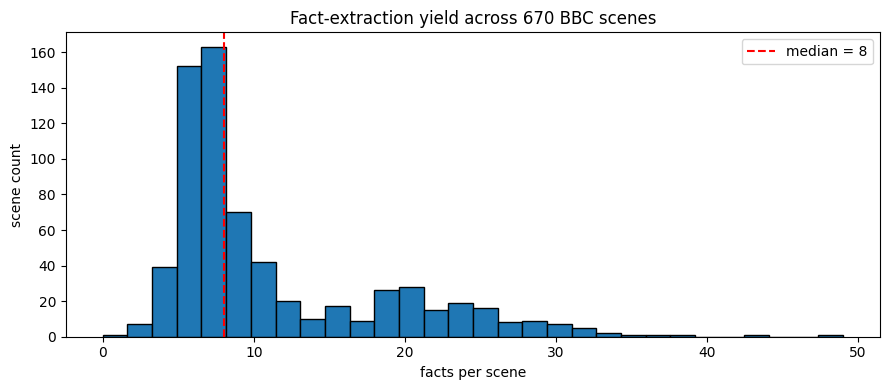

In [21]:
import matplotlib.pyplot as plt

facts_per_scene = df_facts["n_facts"]
print(facts_per_scene.describe().round(2))

plt.figure(figsize=(9, 4))
plt.hist(facts_per_scene, bins=30, edgecolor="black")
plt.axvline(facts_per_scene.median(), color="red", linestyle="--",
            label=f"median = {facts_per_scene.median():.0f}")
plt.xlabel("facts per scene")
plt.ylabel("scene count")
plt.title(f"Fact-extraction yield across {len(df_facts)} BBC scenes")
plt.legend()
plt.tight_layout()
plt.show()


category_broad
entity       2516
relation     1421
attribute    1384
event        1197
action        721
global        219
other          26
Name: count, dtype: int64


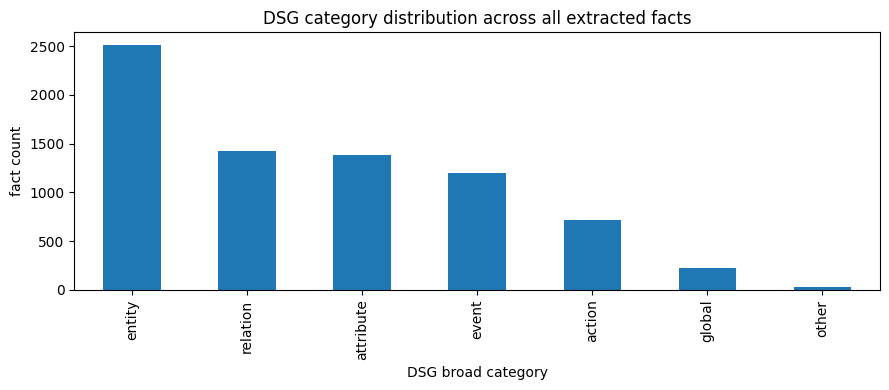

In [22]:
category_counts = (
    df_facts_long["category_broad"].fillna("unparseable").value_counts()
)
print(category_counts)

plt.figure(figsize=(9, 4))
category_counts.plot(kind="bar")
plt.xlabel("DSG broad category")
plt.ylabel("fact count")
plt.title("DSG category distribution across all extracted facts")
plt.tight_layout()
plt.show()


  .apply(lambda g: g.head(5))



Top-5 subcategories per broad category:
category_broad category_detailed  count
        action            (none)    721
     attribute             state    674
     attribute             color    266
     attribute           texture    192
     attribute             scale     91
     attribute             shape     37
        entity             whole   2302
        entity              part    213
        entity             scale      1
         event         ambiguity   1050
         event          temporal    141
         event           spatial      3
         event    transformation      2
         event        transition      1
        global            (none)    219
         other             count     22
         other    text rendering      4
      relation           spatial   1358
      relation          temporal     59
      relation          contrast      3
      relation           purpose      1


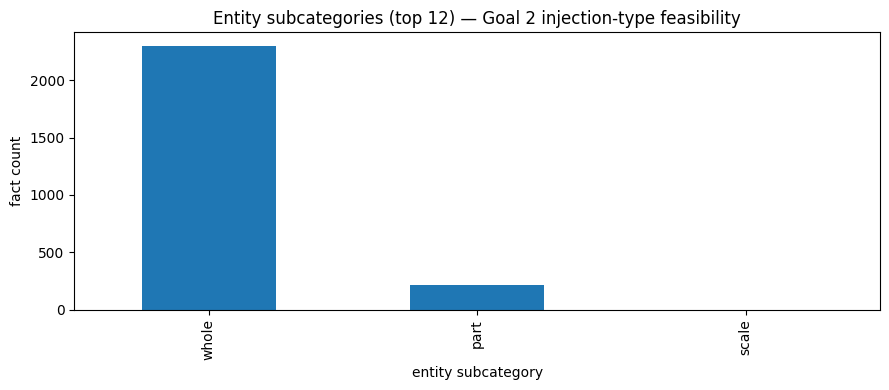

In [23]:
# Top-K subcategories per broad category
subcats = (
    df_facts_long
    .assign(category_detailed=lambda d: d["category_detailed"].replace("", "(none)").fillna("(none)"))
    .groupby(["category_broad", "category_detailed"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["category_broad", "count"], ascending=[True, False])
)

print("Top-5 subcategories per broad category:")
top_per_cat = (
    subcats.groupby("category_broad", group_keys=False)
    .apply(lambda g: g.head(5))
)
print(top_per_cat.to_string(index=False))

entity_subs = (
    df_facts_long[df_facts_long["category_broad"] == "entity"]["category_detailed"]
    .replace("", "(none)")
    .fillna("(none)")
    .value_counts()
    .head(12)
)

plt.figure(figsize=(9, 4))
entity_subs.plot(kind="bar")
plt.xlabel("entity subcategory")
plt.ylabel("fact count")
plt.title("Entity subcategories (top 12) — Goal 2 injection-type feasibility")
plt.tight_layout()
plt.show()


#### Analysis Conclusions

* **Length.** BBC scenes average **48.3 s** (median 40.5 s, range 0.8-208 s) against
  MSR-VTT's ~ 15 s mean and 10–32 s cap (Xu et al., CVPR 2016). Mean-to-mean this is a
  **~3.2× stretch**; the longest BBC scene is **6.5× longer** than anything in MSR-VTT.
  The FIFA pipeline was not validated on content this long, so the extractor is being
  asked to summarize a description of 30 s+ of multi-shot cinematic content into a
  single tuple set. This is the kind of content we want to test the FIFA methodology on.

### Generate Questions

  Rewrite each atomic tuple as a natural-language yes/no question of the form
  `id | question`, keyed by the same fact IDs assigned in the previous step.
  These questions are what the downstream VQA model answers directly from the
  video — its yes/no responses become the raw faithfulness signal per fact, one
  signal per tuple.

In [24]:
import time


def batch_generate_questions(df, llm, config, pace_seconds: float = 0.0):
    """Generate questions per scene with optional pacing between requests.

    Set pace_seconds > 0 when the LLM is rate-limited (e.g. gpt-4o Tier 1
    at 30k TPM). Pacing spreads request timing so the SDK's exponential
    backoff has to handle fewer 429 bursts.
    """
    all_questions_records = []
    total = len(df)

    print(
        f"Starting question generation for {total} scenes "
        f"(pace_seconds={pace_seconds})..."
    )

    for idx, row in df.iterrows():
        try:
            description = row['description']
            raw_tuples = row['raw_tuples']
            facts = json.loads(row['facts_json'])
            valid_ids = {f['id'] for f in facts}

            # Prepare prompt using the utility
            question_prompt = fifa.make_prompt(
                examples=fifa._QUESTION_EXAMPLES,
                test_input="\n".join([description, raw_tuples]),
                test_query="What happens in the scene?",
                preamble=fifa._QUESTION_PREAMBLE,
                task="question"
            )

            # Get completion from LLM
            raw_question_output = llm.completion(
                prompt=question_prompt,
                config=config
            )

            # Parse questions
            questions, _ = parse_questions(raw_question_output, valid_ids=valid_ids)

            all_questions_records.append({
                "video_id": row['video_id'],
                "scene_id": row['scene_id'],
                "raw_questions": raw_question_output,
                "questions_json": json.dumps(questions)
            })

            if (idx + 1) % 10 == 0:
                print(f"  Processed {idx + 1}/{total} scenes")

        except Exception as e:
            print(f"  Error processing index {idx}: {e}")

        if pace_seconds > 0:
            time.sleep(pace_seconds)

    return pd.DataFrame(all_questions_records)


In [25]:
# gpt-4o Tier 1 = 30k TPM. Each request is ~5-6k tokens, so pacing at ~6s
# keeps the average request rate under the limit and lets the SDK's built-in
# exponential backoff handle occasional bursts. Bump to 10-12s if 429s persist,
# drop to 0 if you're on a higher tier or using a non-rate-limited backend.
QUESTIONS_PACE_SECONDS = 6.0

if QUESTIONS_CACHE_PATH.exists():
    df_questions = pd.read_csv(QUESTIONS_CACHE_PATH)
    print(f"Scene questions already at: {QUESTIONS_CACHE_PATH}")
else:
    QUESTIONS_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_questions = batch_generate_questions(
        df_facts,
        extractor_llm,
        QUESTION_GENERATION_CONFIG,
        pace_seconds=QUESTIONS_PACE_SECONDS,
    )
    df_questions.to_csv(QUESTIONS_CACHE_PATH, index=False)
    print(f"Results successfully cached to: {QUESTIONS_CACHE_PATH}")


Scene questions already at: /content/bbc/runs/qwen35-gpt4o/scene_questions.csv


In [ ]:
display(df_questions.head())

,video_id,scene_id,raw_questions,questions_json
0,bbc_01,scene_000.mp4,1 | Is there a black screen?\n2 | Is there Ear...,"{""1"": ""Is there a black screen?"", ""2"": ""Is the..."
1,bbc_01,scene_001.mp4,1 | Is there a camera?\n2 | Is there a mountai...,"{""1"": ""Is there a camera?"", ""2"": ""Is there a m..."
2,bbc_01,scene_002.mp4,1 | Is there a group of penguins?\n2 | Is ther...,"{""1"": ""Is there a group of penguins?"", ""2"": ""I..."
3,bbc_01,scene_003.mp4,1 | Are there penguins?\n2 | Is there ice?\n3 ...,"{""1"": ""Are there penguins?"", ""2"": ""Is there ic..."
4,bbc_01,scene_004.mp4,1 | Is there a sun?\n2 | Is there a mountain r...,"{""1"": ""Is there a sun?"", ""2"": ""Is there a moun..."


#### Question-generation analysis

The next four plots characterize the fact→question conversion step on the BBC
scene set. Each addresses a distinct pipeline-quality concern the proposal calls
out:

1. **Coverage per scene** — fraction of extracted facts that received a question.
   Directly comparable to the FIFA paper's Table 2 metric (99.04% fact-to-question
   conversion accuracy).
2. **Yes/no shape validity** — fraction of generated questions that open with a
   yes/no verb. The downstream scoring code (`_AFFIRM` / `_DENY` sets) assumes
   yes/no answers; malformed questions poison the fact-level score independently
   of VQA quality.
3. **Coverage by DSG category** — which fact types the generator handles reliably
   vs. drops. Cross-references FIFA's Table 6 per-category VQA accuracy for
   compounded-loss analysis.
4. **Question length by category** — mean and spread of word count per fact
   category. Long, compound questions on temporal or event facts compound the VQA
   difficulty already visible in FIFA Table 6.


In [26]:
import json
import pandas as pd

df_facts["parsed_facts"] = df_facts["facts_json"].apply(json.loads)
df_facts["n_facts"] = df_facts["parsed_facts"].apply(len)

df_questions["parsed_questions"] = df_questions["questions_json"].apply(
    lambda s: {int(k): v for k, v in json.loads(s).items()}
)
df_questions["n_questions"] = df_questions["parsed_questions"].apply(len)

qs_by_scene = df_questions.set_index(["video_id", "scene_id"])[["parsed_questions"]]

df_qcoverage = df_facts.set_index(["video_id", "scene_id"])[["n_facts"]].copy()

# Reindex qs_by_scene to match df_qcoverage's index, filling missing parsed_questions with empty dicts.
# This ensures n_questions will always be an integer and not NaN.
reindexed_qs_by_scene = qs_by_scene.reindex(df_qcoverage.index)
reindexed_qs_by_scene["parsed_questions"] = reindexed_qs_by_scene["parsed_questions"].fillna({})
# Explicitly check for dict type before applying len to prevent TypeError on floats
df_qcoverage["n_questions"] = reindexed_qs_by_scene["parsed_questions"].apply(lambda x: len(x) if isinstance(x, dict) else 0)

df_qcoverage["coverage"] = (
    df_qcoverage["n_questions"] / df_qcoverage["n_facts"].replace(0, pd.NA)
)
df_qcoverage = df_qcoverage.reset_index()

records = []
for _, row in df_facts.iterrows():
    key = (row["video_id"], row["scene_id"])
    q_dict = {}
    try:
        # Correctly access the parsed_questions dictionary for the current scene
        q_dict_potential = qs_by_scene.loc[key, "parsed_questions"]
        if isinstance(q_dict_potential, dict):
            q_dict = q_dict_potential
    except KeyError:
        # If the scene has no questions in df_questions, q_dict remains empty
        pass

    for f in row["parsed_facts"]:
        if not isinstance(f, dict):
            continue
        fid = f.get("id")
        records.append({
            "video_id": row["video_id"],
            "scene_id": row["scene_id"],
            "fact_id": fid,
            "category_broad": f.get("category_broad"),
            "question": q_dict.get(fid),
        })
df_qfacts_long = pd.DataFrame(records)
df_qfacts_long["has_question"] = df_qfacts_long["question"].notna()

n_facts = len(df_qfacts_long)
n_with_q = int(df_qfacts_long["has_question"].sum())
print(f"{len(df_qcoverage)} scenes, {n_facts} facts, "
      f"{n_with_q} received a question ({n_with_q / n_facts:.2%} overall)")

670 scenes, 7484 facts, 7484 received a question (100.00% overall)


count     669.0
unique      1.0
top         1.0
freq      669.0
Name: coverage, dtype: float64


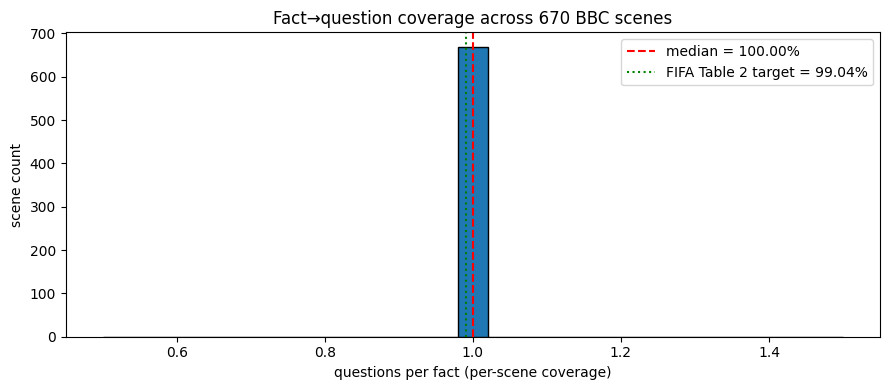

In [27]:
import matplotlib.pyplot as plt

coverage = df_qcoverage["coverage"].dropna()
print(coverage.describe().round(3))

plt.figure(figsize=(9, 4))
plt.hist(coverage, bins=25, edgecolor="black")
plt.axvline(coverage.median(), color="red", linestyle="--",
            label=f"median = {coverage.median():.2%}")
plt.axvline(0.9904, color="green", linestyle=":",
            label="FIFA Table 2 target = 99.04%")
plt.xlabel("questions per fact (per-scene coverage)")
plt.ylabel("scene count")
plt.title(f"Fact→question coverage across {len(df_qcoverage)} BBC scenes")
plt.legend()
plt.tight_layout()
plt.show()


yes/no-shaped questions: 7484 / 7484 (100.00%)


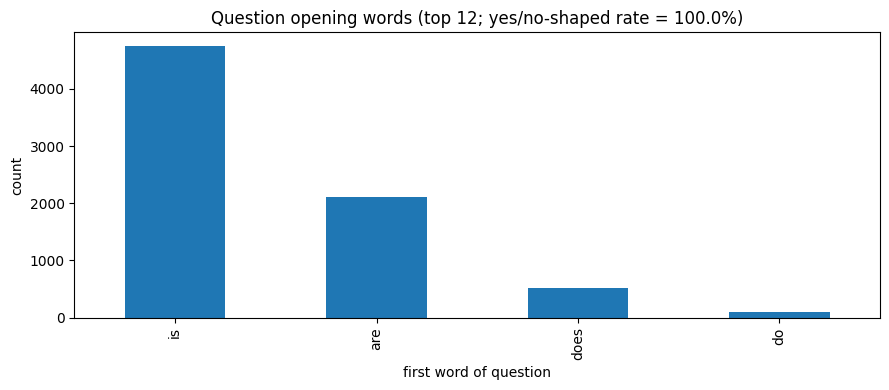

In [28]:
import re

YESNO_OPENERS = {
    "is", "are", "does", "do", "did", "has", "have", "was", "were",
    "can", "could", "should", "would", "will", "may", "might",
}


def opener(q):
    if not isinstance(q, str):
        return None
    m = re.match(r"^\s*([A-Za-z]+)", q.lower())
    return m.group(1) if m else None


df_qfacts_long["opener"] = df_qfacts_long["question"].apply(opener)
opener_counts = df_qfacts_long["opener"].fillna("(no question)").value_counts()

yesno_ok = df_qfacts_long["opener"].isin(YESNO_OPENERS)
n_with_q = int(df_qfacts_long["has_question"].sum())
yesno_rate = int(yesno_ok.sum()) / n_with_q if n_with_q else 0.0

print(f"yes/no-shaped questions: {int(yesno_ok.sum())} / {n_with_q} ({yesno_rate:.2%})")

top_openers = opener_counts.head(12)
plt.figure(figsize=(9, 4))
top_openers.plot(kind="bar")
plt.xlabel("first word of question")
plt.ylabel("count")
plt.title(f"Question opening words (top 12; yes/no-shaped rate = {yesno_rate:.1%})")
plt.tight_layout()
plt.show()


                coverage  n_with_question  n_facts
category_broad                                    
entity               1.0             2516     2516
relation             1.0             1421     1421
attribute            1.0             1384     1384
event                1.0             1197     1197
action               1.0              721      721
global               1.0              219      219
other                1.0               26       26


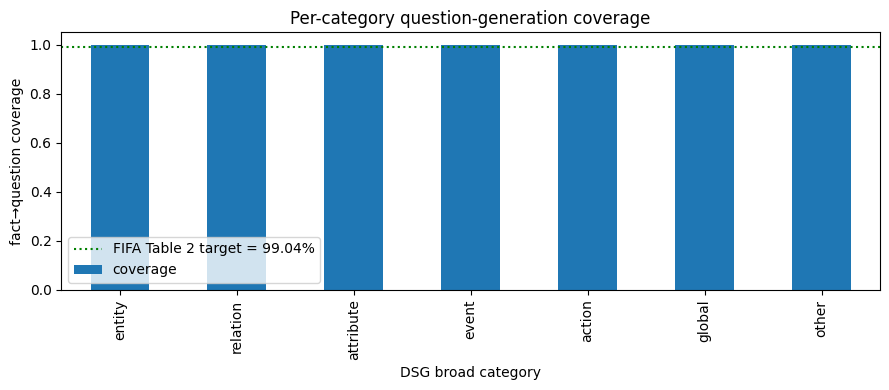

In [29]:
category_coverage = (
    df_qfacts_long
    .groupby("category_broad")["has_question"]
    .agg(coverage="mean", n_with_question="sum", n_facts="count")
    .sort_values("n_facts", ascending=False)
)
print(category_coverage.round(3))

plt.figure(figsize=(9, 4))
category_coverage["coverage"].plot(kind="bar")
plt.axhline(0.9904, color="green", linestyle=":",
            label="FIFA Table 2 target = 99.04%")
plt.xlabel("DSG broad category")
plt.ylabel("fact→question coverage")
plt.ylim(0, 1.05)
plt.title("Per-category question-generation coverage")
plt.legend()
plt.tight_layout()
plt.show()


  plt.boxplot(groups, labels=wc_stats.index.tolist(), showfliers=False)



                mean  median   std  count
category_broad                           
entity          4.01     4.0  0.95   2516
relation        7.03     7.0  1.51   1421
attribute       4.84     4.0  1.31   1384
event           9.87     9.0  3.25   1197
action          6.35     7.0  1.68    721
global          4.80     5.0  0.47    219
other           5.31     5.5  0.97     26


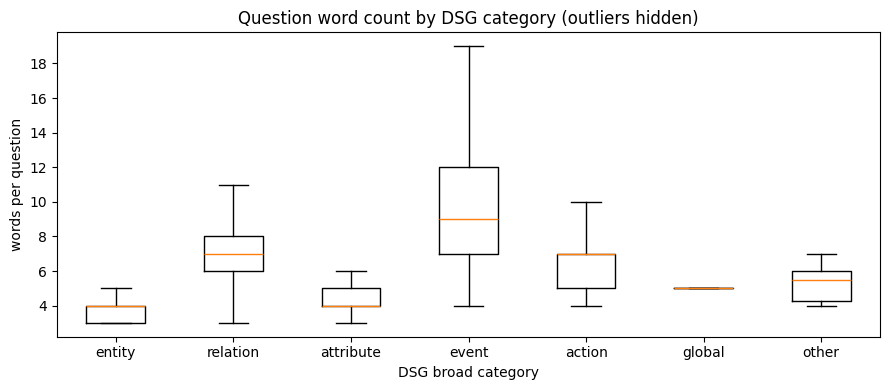

In [30]:
df_qfacts_long["question_wc"] = df_qfacts_long["question"].apply(
    lambda q: len(q.split()) if isinstance(q, str) else None
)

wc_stats = (
    df_qfacts_long
    .dropna(subset=["question_wc", "category_broad"])
    .groupby("category_broad")["question_wc"]
    .agg(mean="mean", median="median", std="std", count="count")
    .sort_values("count", ascending=False)
)
print(wc_stats.round(2))

groups = [
    df_qfacts_long.loc[
        (df_qfacts_long["category_broad"] == cat)
        & df_qfacts_long["question_wc"].notna(),
        "question_wc",
    ].values
    for cat in wc_stats.index
]

plt.figure(figsize=(9, 4))
plt.boxplot(groups, labels=wc_stats.index.tolist(), showfliers=False)
plt.title("Question word count by DSG category (outliers hidden)")
plt.xlabel("DSG broad category")
plt.ylabel("words per question")
plt.tight_layout()
plt.show()


#### Analysis Conclusions

**Coverage.** 7,484 / 7,484 = **100.00%** fact to question conversion across
670 BBC scenes

**Yes/no shape validity: 100%.** Every one of 7,484 questions opens with a
yes/no verb. The downstream scoring code (`_AFFIRM` / `_DENY` sets in the Verify
Facts section) assumes yes/no answers; open-ended drift would silently poison
the fact-level score independently of VQA quality.

**Question length by category** — These findings matter most for assessing the risks to our research question. Events produce ~2.5x longer questions than entities (9.9 vs 4.0 words) with 3.4x the standard deviation (3.25 vs 0.95). The two proposal-relevant implications are:

- **Compounded difficulty on event/temporal categories.** Cross-referencing with
  FIFA Table 6, entity/attribute VQA accuracy runs 73-90% while events drop to
  52-63%. The questions asked of the VQA in the already-weakest category are
  also the longest and most variable.

- **Per-category injection sensitivity for Goal 2.** Injecting a hallucination
  into an event fact ("Does the man walk from the doorway to the table while
  carrying a tray?") gives the VQA multiple partial correctnesses to hang a
  "yes" on.

Pipeline-quality metrics (100% coverage, 100% yes/no validity)
show the fact and question conversion step is robust on cinematic content which meets Goal 1. Category-conditioned question length quantifies where downstream
verification is likely hardest, event/temporal categories, providing concrete
evidence for Risk 1 and a principled reason to report Goal 2 injection
sensitivity per category rather than aggregated.


### Dependency Graph Generation



In [31]:
def batch_generate_dependencies(df, llm, config, pace_seconds: float = 0.0):
    """Generate dependency lists per scene with optional pacing between requests.

    Set pace_seconds > 0 when the LLM is rate-limited (e.g. gpt-4o Tier 1
    at 30k TPM). Pacing spreads request timing so the SDK's exponential
    backoff has to handle fewer 429 bursts.
    """
    all_deps_records = []
    total = len(df)

    print(
        f"Starting dependency generation for {total} scenes "
        f"(pace_seconds={pace_seconds})..."
    )

    for idx, row in df.iterrows():
        try:
            description = row['description']
            raw_tuples = row['raw_tuples']
            facts = json.loads(row['facts_json'])
            valid_ids = {f['id'] for f in facts}

            # Prepare prompt using the utility
            dependency_prompt = fifa.make_prompt(
                examples=fifa._DEPENDENCY_EXAMPLES,
                test_input="\n".join([description, raw_tuples]),
                test_query="What happens in the scene?",
                preamble=fifa._DEPENDENCY_PREAMBLE,
                task="dependency"
            )

            # Get completion from LLM
            raw_dependency_output = llm.completion(
                prompt=dependency_prompt,
                config=config
            )

            # Parse dependencies
            dependencies, _, _ = parse_dependencies(
                raw_dependency_output,
                valid_ids=valid_ids
            )

            all_deps_records.append({
                "video_id": row['video_id'],
                "scene_id": row['scene_id'],
                "raw_dependencies": raw_dependency_output,
                "dependencies_json": json.dumps(dependencies)
            })

            if (idx + 1) % 10 == 0:
                print(f"  Processed {idx + 1}/{total} scenes")

        except Exception as e:
            print(f"  Error processing index {idx}: {e}")

        if pace_seconds > 0:
            time.sleep(pace_seconds)

    return pd.DataFrame(all_deps_records)


In [32]:
# gpt-4o Tier 1 = 30k TPM. Each request is ~5-6k tokens, so pacing at ~6s
# keeps the average request rate under the limit and lets the SDK's built-in
# exponential backoff handle occasional bursts. Bump to 10-12s if 429s persist,
# drop to 0 if you're on a higher tier or using a non-rate-limited backend.
DEPENDENCIES_PACE_SECONDS = 6.0

if GRAPH_CACHE_PATH.exists():
    df_dependencies = pd.read_csv(GRAPH_CACHE_PATH)
    print(f"Scene dependencies already at: {GRAPH_CACHE_PATH}")
else:
    GRAPH_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_dependencies = batch_generate_dependencies(
        df_facts,
        extractor_llm,
        GRAPH_GENERATION_CONFIG,
        pace_seconds=DEPENDENCIES_PACE_SECONDS,
    )
    df_dependencies.to_csv(GRAPH_CACHE_PATH, index=False)
    print(f"Results successfully cached to: {GRAPH_CACHE_PATH}")


Scene dependencies already at: /content/bbc/runs/qwen35-gpt4o/scene_dependencies.csv


In [33]:
display(df_dependencies.head())

,video_id,scene_id,raw_dependencies,dependencies_json
0,bbc_01,scene_000.mp4,1 | 0 \n2 | 0 \n3 | 0 \n4 | 0 \n5 | 0 \n6...,"{""1"": [], ""2"": [], ""3"": [], ""4"": [], ""5"": [], ..."
1,bbc_01,scene_001.mp4,"1 | 0\n2 | 0\n3 | 0\n4 | 1\n5 | 3\n6 | 4,5","{""1"": [], ""2"": [], ""3"": [], ""4"": [1], ""5"": [3]..."
2,bbc_01,scene_002.mp4,"1 | 0\n2 | 0\n3 | 0\n4 | 1\n5 | 1,2\n6 | 2,3\n...","{""1"": [], ""2"": [], ""3"": [], ""4"": [1], ""5"": [1,..."
3,bbc_01,scene_003.mp4,1 | 0 \n2 | 0 \n3 | 0 \n4 | 1 \n5 | 1 \n6...,"{""1"": [], ""2"": [], ""3"": [], ""4"": [1], ""5"": [1]..."
4,bbc_01,scene_004.mp4,"1 | 0\n2 | 0\n3 | 0\n4 | 1\n5 | 1\n6 | 1,2\n7 ...","{""1"": [], ""2"": [], ""3"": [], ""4"": [1], ""5"": [1]..."


#### Dependency-graph analysis

The next four plots characterize the STSDG structure the extractor produced on
the BBC scene set. Each addresses a distinct pipeline-quality or applicability
concern the proposal calls out:

1. **Root-fact rate per scene** — fraction of facts with no declared parents.
   High root rate means the graph is flat and FIFA's transitive score
   propagation is effectively inactive; direct evidence for the proposal's
   Risk 1.
2. **DAG validity rate** — fraction of scenes that produced a well-formed
   acyclic graph. Directly comparable to the FIFA paper's Table 2 metric
   (99.03–99.06% dependency validity ratio).
3. **Root rate by DSG category** — sanity check on taxonomy adherence. Entities
   and attributes should dominate the root layer (foundational claims);
   actions and events should typically have parents (grounded in entities).
4. **Event fan-out per entity** — mean number of event-category descendants
   per entity (transitively through the DAG). DSG caps chain depth at ~3
   because events are terminal (no `event → event` edges — FIFA's own gold
   examples top out at depth 3), so chain depth alone can't distinguish a
   static scene from a temporally rich one. Event fan-out is the right proxy:
   5 events grounded in one entity is richer than 1 event. Relevant to Risk 1
   (long-range temporal modeling) and Goal 2 (injection at high-fan-out roots
   has bigger effects).


In [34]:
import json
import pandas as pd
import networkx as nx

df_dependencies["parsed_deps"] = df_dependencies["dependencies_json"].apply(
    lambda s: {int(k): [int(p) for p in v] for k, v in json.loads(s).items()}
)

deps_by_scene = (
    df_dependencies.set_index(["video_id", "scene_id"])["parsed_deps"].to_dict()
)


def _scene_graph_stats(fact_ids, deps):
    G = nx.DiGraph()
    G.add_nodes_from(fact_ids)
    for child, parents in deps.items():
        if child not in fact_ids:
            continue
        for p in parents:
            if p in fact_ids and p != child:
                G.add_edge(p, child)

    n_edges = G.number_of_edges()
    is_dag = nx.is_directed_acyclic_graph(G) if len(G) else True
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    n_roots = len(roots)
    n_facts = len(fact_ids)

    max_depth = None
    if is_dag and n_facts > 0:
        depths = {}
        for n in nx.topological_sort(G):
            preds = list(G.predecessors(n))
            depths[n] = 1 + max(depths[p] for p in preds) if preds else 0
        max_depth = max(depths.values()) if depths else 0

    return {
        "n_facts": n_facts,
        "n_edges": n_edges,
        "n_roots": n_roots,
        "root_rate": n_roots / n_facts if n_facts else None,
        "max_depth": max_depth,
        "is_valid_dag": is_dag,
    }


stat_rows = []
long_rows = []
for _, row in df_facts.iterrows():
    key = (row["video_id"], row["scene_id"])
    facts = [f for f in row["parsed_facts"] if isinstance(f, dict)]
    fact_ids = {f["id"] for f in facts}
    deps = deps_by_scene.get(key, {}) or {}

    stat_rows.append({
        "video_id": row["video_id"],
        "scene_id": row["scene_id"],
        **_scene_graph_stats(fact_ids, deps),
    })

    for f in facts:
        fid = f.get("id")
        parents = deps.get(fid, [])
        long_rows.append({
            "video_id": row["video_id"],
            "scene_id": row["scene_id"],
            "fact_id": fid,
            "category_broad": f.get("category_broad"),
            "n_parents": len(parents),
            "is_root": len(parents) == 0,
        })

df_dstats = pd.DataFrame(stat_rows)
df_dfacts_long = pd.DataFrame(long_rows)

print(f"{len(df_dstats)} scenes, {len(df_dfacts_long)} facts, "
      f"{int(df_dstats['n_edges'].sum())} total dependency edges")


670 scenes, 7484 facts, 7473 total dependency edges


count    669.000
mean       0.410
std        0.129
min        0.069
25%        0.333
50%        0.385
75%        0.500
max        0.909
Name: root_rate, dtype: float64
scenes with 0 edges (all facts are roots): 1


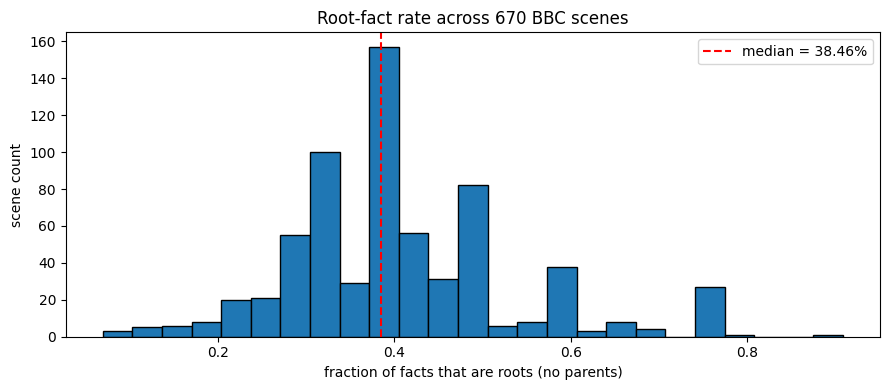

In [35]:
import matplotlib.pyplot as plt

root_rate = df_dstats["root_rate"].dropna()
print(root_rate.describe().round(3))
print(f"scenes with 0 edges (all facts are roots): "
      f"{int((df_dstats['n_edges'] == 0).sum())}")

plt.figure(figsize=(9, 4))
plt.hist(root_rate, bins=25, edgecolor="black")
plt.axvline(root_rate.median(), color="red", linestyle="--",
            label=f"median = {root_rate.median():.2%}")
plt.xlabel("fraction of facts that are roots (no parents)")
plt.ylabel("scene count")
plt.title(f"Root-fact rate across {len(df_dstats)} BBC scenes")
plt.legend()
plt.tight_layout()
plt.show()


In [36]:
n_valid = int(df_dstats["is_valid_dag"].sum())
n_total = len(df_dstats)
validity_rate = n_valid / n_total if n_total else 0.0

print(f"DAG-valid scenes:      {n_valid} / {n_total} ({validity_rate:.2%})")
print(f"FIFA Table 2 target:   99.03% – 99.06% dependency validity ratio")

invalid = df_dstats[~df_dstats["is_valid_dag"]]
if not invalid.empty:
    print(f"\nCyclic scenes ({len(invalid)}):")
    print(
        invalid[["video_id", "scene_id", "n_facts", "n_edges"]]
        .head(20)
        .to_string(index=False)
    )


DAG-valid scenes:      670 / 670 (100.00%)
FIFA Table 2 target:   99.03% – 99.06% dependency validity ratio


                root_rate  n_facts
category_broad                    
entity              0.922     2516
relation            0.018     1421
attribute           0.145     1384
event               0.003     1197
action              0.108      721
global              1.000      219
other               0.077       26


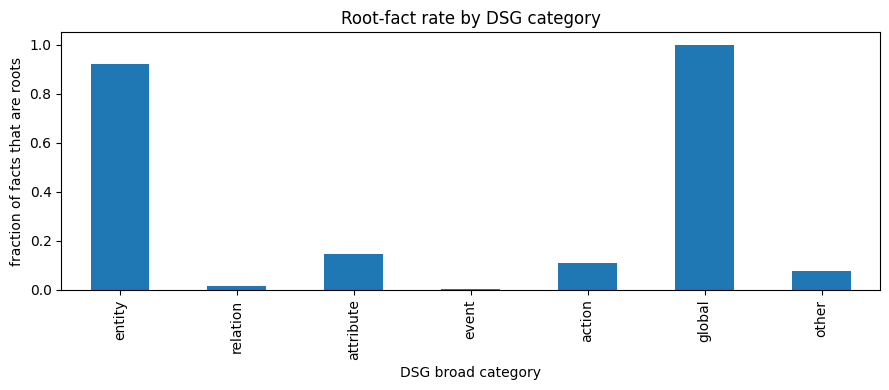

In [37]:
cat_root = (
    df_dfacts_long
    .groupby("category_broad")["is_root"]
    .agg(root_rate="mean", n_facts="count")
    .sort_values("n_facts", ascending=False)
)
print(cat_root.round(3))

plt.figure(figsize=(9, 4))
cat_root["root_rate"].plot(kind="bar")
plt.xlabel("DSG broad category")
plt.ylabel("fraction of facts that are roots")
plt.ylim(0, 1.05)
plt.title("Root-fact rate by DSG category")
plt.tight_layout()
plt.show()


       n_events  n_entities  mean_event_fanout  max_event_fanout
count    669.00      669.00             669.00            669.00
mean       1.79        3.76               0.94              1.34
std        1.50        2.58               0.55              1.04
min        0.00        1.00               0.00              0.00
25%        1.00        2.00               0.75              1.00
50%        1.00        3.00               1.00              1.00
75%        2.00        4.00               1.25              2.00
max        8.00       21.00               3.00              6.00


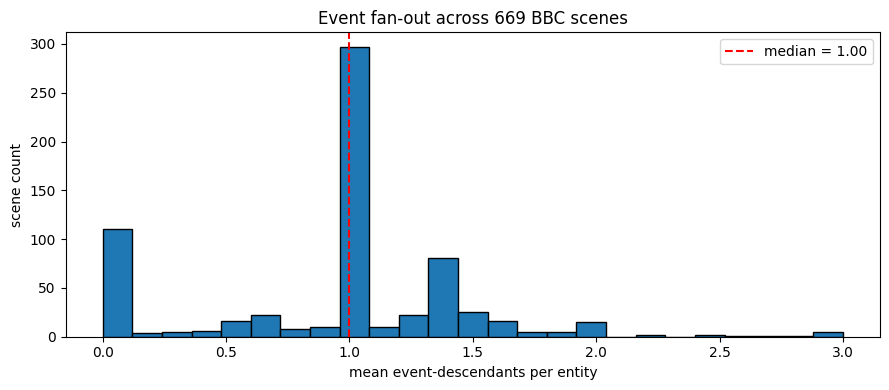

In [38]:
import networkx as nx

event_fanout_rows = []

for _, row in df_facts.iterrows():
    key = (row["video_id"], row["scene_id"])
    facts = [f for f in row["parsed_facts"] if isinstance(f, dict)]
    cat_by_id = {f["id"]: f.get("category_broad") for f in facts}
    fact_ids = set(cat_by_id)
    deps = deps_by_scene.get(key, {}) or {}

    G = nx.DiGraph()
    G.add_nodes_from(fact_ids)
    for child, parents in deps.items():
        if child not in fact_ids:
            continue
        for p in parents:
            if p in fact_ids and p != child:
                G.add_edge(p, child)

    if not nx.is_directed_acyclic_graph(G) or not fact_ids:
        event_fanout_rows.append({
            "video_id": row["video_id"],
            "scene_id": row["scene_id"],
            "n_events": None,
            "n_entities": None,
            "mean_event_fanout": None,
            "max_event_fanout": None,
        })
        continue

    n_events = sum(1 for c in cat_by_id.values() if c == "event")
    entities = [fid for fid, c in cat_by_id.items() if c == "entity"]

    fanouts = [
        sum(1 for d in nx.descendants(G, e) if cat_by_id.get(d) == "event")
        for e in entities
    ]

    event_fanout_rows.append({
        "video_id": row["video_id"],
        "scene_id": row["scene_id"],
        "n_events": n_events,
        "n_entities": len(entities),
        "mean_event_fanout": sum(fanouts) / len(fanouts) if fanouts else 0.0,
        "max_event_fanout": max(fanouts) if fanouts else 0,
    })

df_event_fanout = pd.DataFrame(event_fanout_rows)
print(df_event_fanout[["n_events", "n_entities", "mean_event_fanout", "max_event_fanout"]].describe().round(2))

fanout = df_event_fanout["mean_event_fanout"].dropna()
plt.figure(figsize=(9, 4))
plt.hist(fanout, bins=25, edgecolor="black")
plt.axvline(fanout.median(), color="red", linestyle="--",
            label=f"median = {fanout.median():.2f}")
plt.xlabel("mean event-descendants per entity")
plt.ylabel("scene count")
plt.title(f"Event fan-out across {len(fanout)} BBC scenes")
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
entity_long = df_dfacts_long.merge(
    df_facts_long[["video_id", "scene_id", "fact_id", "category_detailed"]]
    if "fact_id" in df_facts_long.columns
    else df_dfacts_long,  # fallback
    on=["video_id", "scene_id", "fact_id"],
    how="left",
)

df_facts_for_merge = (
    df_facts.explode("parsed_facts")
    .assign(
        fact_id=lambda x: x["parsed_facts"].apply(lambda p: p.get("id") if isinstance(p, dict) else None),
        category_detailed=lambda x: x["parsed_facts"].apply(lambda p: p.get("category_detailed") if isinstance(p, dict) else None)
    )
    [["video_id", "scene_id", "fact_id", "category_detailed"]]
    .dropna(subset=["fact_id", "category_detailed"])
)

entity_root = (
    df_dfacts_long[df_dfacts_long["category_broad"] == "entity"]
    .merge(df_facts_for_merge, # Use the correctly constructed DataFrame
            on=["video_id", "scene_id", "fact_id"], how="left")
    .groupby("category_detailed")["is_root"]
    .agg(root_rate="mean", n="count")
)
print(entity_root.round(3))

                   root_rate     n
category_detailed                 
part                   0.136   213
scale                  0.000     1
whole                  0.995  2302


#### Analysis Conclusions

* The dependency-generation step is structurally sound and
supports using FIFA as a baseline.
* A real concern for this evaluation is that we're capturing 3.5× fewer event tuples per second, and 88% of those events are untyped rather than cleanly temporal. Resolving the fraction of untyped events that represent real temporal action is a follow-up.


    | dataset | mean events/item | mean length | events/second |
    | --- | --- | --- | --- |
    | FIFA video ICL (video_001–003) | ~2.0 | ~15 s (MSR-VTT) | **0.13** |
    | **BBC** | **1.79** | **48.3 s** | **0.037** |

  There can be a number of reasons for this that we didn't have time to investigate.
  - **VLM prompt**: It doesn't explicitly enumerate events ("List every distinct action or event, in temporal order").
  
  - **Undersampling**: We didn't sample enough of the frames to change everything happening in longer segments.
  
  - **Less Eventful**: The BBC movies could are arguable less eventful. There's often a lot of camera motion arond a particular subject.

  As a result this results in our analysis being less complete around evaluating the results on more complex temporal chains.



### Visualize Graph

In [40]:
from graph import build_fifa_graph, draw_fifa_graph


In [41]:
first_scene_facts_row = df_facts.iloc[0]
first_scene_questions_row = df_questions[
    (df_questions['video_id'] == first_scene_facts_row['video_id']) &
    (df_questions['scene_id'] == first_scene_facts_row['scene_id'])
].iloc[0]
first_scene_dependencies_row = df_dependencies[
    (df_dependencies['video_id'] == first_scene_facts_row['video_id']) &
    (df_dependencies['scene_id'] == first_scene_facts_row['scene_id'])
].iloc[0]


facts_for_single_scene = json.loads(first_scene_facts_row['facts_json'])


questions_for_single_scene_str_keys = json.loads(first_scene_questions_row['questions_json'])
questions_for_single_scene = {int(k): v for k, v in questions_for_single_scene_str_keys.items()}

dependencies_for_single_scene_str_keys = json.loads(first_scene_dependencies_row['dependencies_json'])
dependencies_for_single_scene = {int(k): v for k, v in dependencies_for_single_scene_str_keys.items()}


G = build_fifa_graph(
    facts_for_single_scene,
    questions_for_single_scene,
    dependencies_for_single_scene,
)

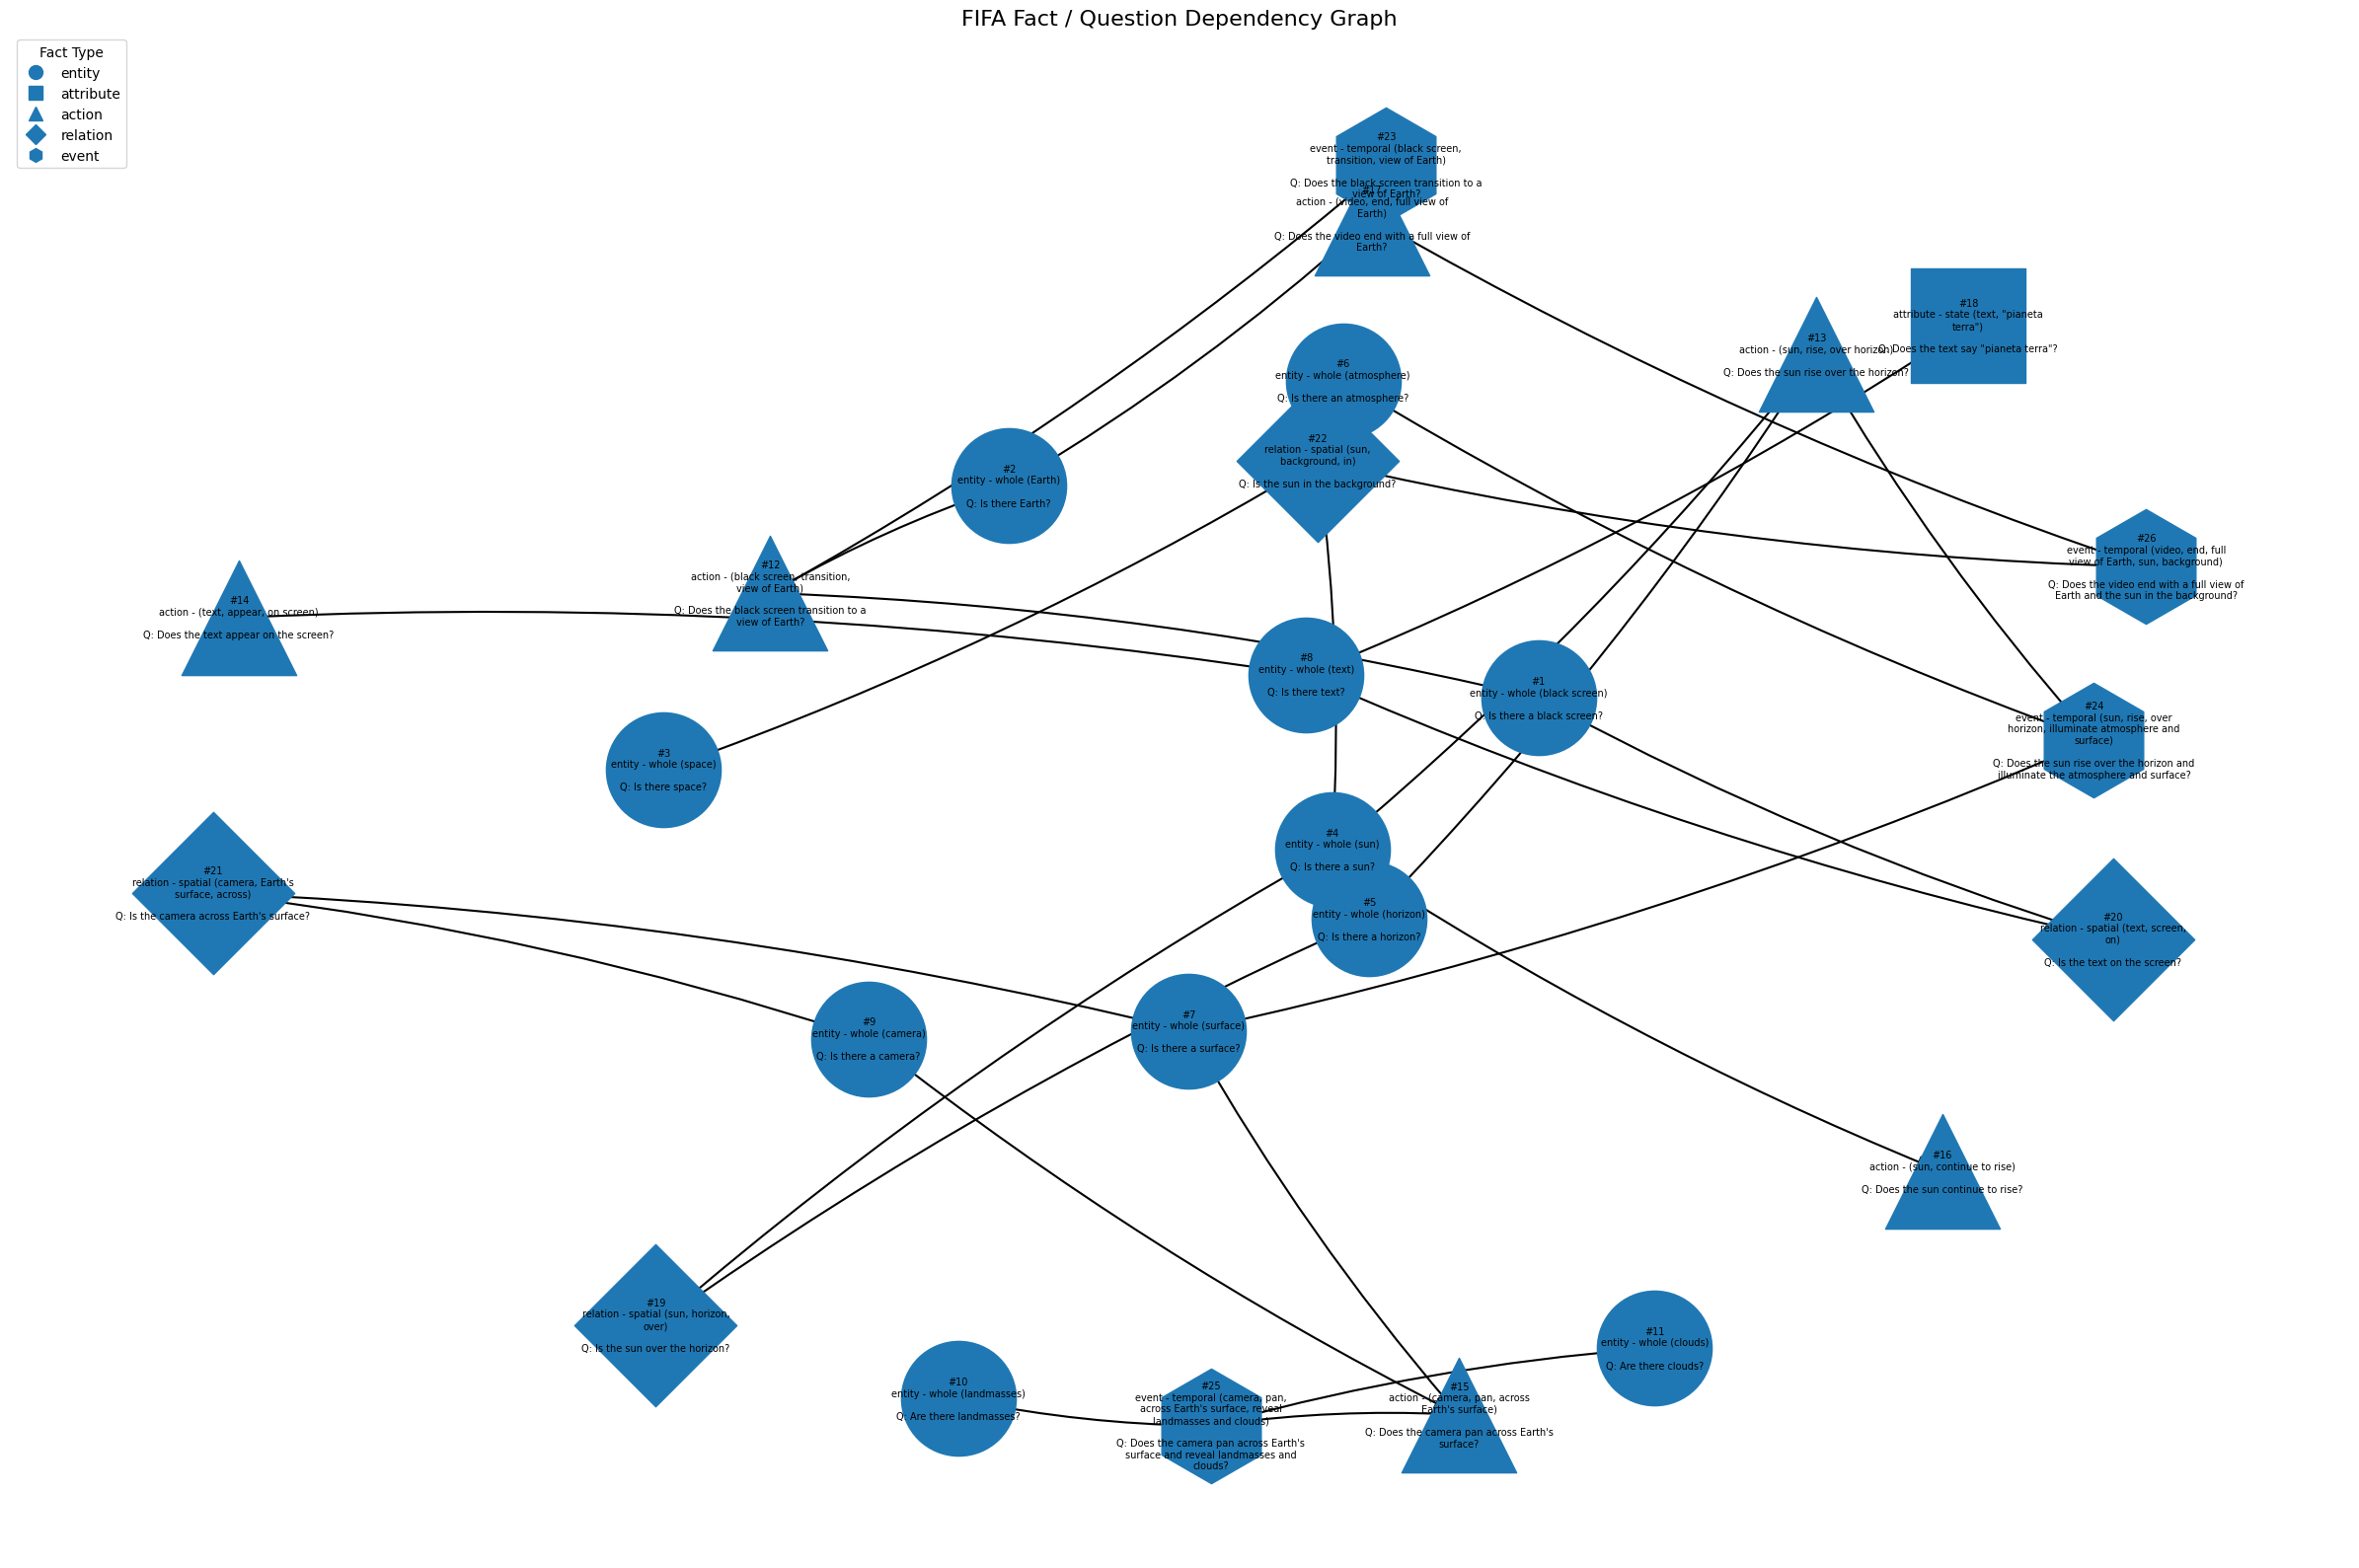

In [42]:
draw_fifa_graph(G)

## Dependency Graph (STSDG)

In [43]:
stsdg = [
    {
        **f,
        "question": questions_for_single_scene.get(f["id"]),
        "parents": [p for p in dependencies_for_single_scene.get(f["id"], []) if p != 0],
    }
    for f in facts_for_single_scene
]

deps_clean = {
    k: [p for p in v if p != 0]
    for k, v in dependencies_for_single_scene.items()
}

id2text = {f["id"]: f["text"] for f in facts_for_single_scene}
for rec in stsdg:
    parents = ", ".join(id2text.get(p, f"?{p}") for p in rec["parents"]) or "-"
    print(f"{rec['id']:>3}  {rec['text']}")
    print(f"     Q: {rec['question']}")
    print(f"     parents: {parents}")

complete = [
    r for r in stsdg
    if r["question"] is not None and r["id"] in dependencies_for_single_scene
]
print(f"\n{len(complete)}/{len(stsdg)} facts have a tuple, question and dependency entry")

  1  entity - whole (black screen)
     Q: Is there a black screen?
     parents: -
  2  entity - whole (Earth)
     Q: Is there Earth?
     parents: -
  3  entity - whole (space)
     Q: Is there space?
     parents: -
  4  entity - whole (sun)
     Q: Is there a sun?
     parents: -
  5  entity - whole (horizon)
     Q: Is there a horizon?
     parents: -
  6  entity - whole (atmosphere)
     Q: Is there an atmosphere?
     parents: -
  7  entity - whole (surface)
     Q: Is there a surface?
     parents: -
  8  entity - whole (text)
     Q: Is there text?
     parents: -
  9  entity - whole (camera)
     Q: Is there a camera?
     parents: -
 10  entity - whole (landmasses)
     Q: Are there landmasses?
     parents: -
 11  entity - whole (clouds)
     Q: Are there clouds?
     parents: -
 12  action - (black screen, transition, view of Earth)
     Q: Does the black screen transition to a view of Earth?
     parents: entity - whole (black screen), entity - whole (Earth)
 13  action 

In [44]:
def gold_dependencies(item_id):
    sub = fifa._TIFA160_DF[fifa._TIFA160_DF.item_id == item_id]
    gold = {}
    for n, raw in enumerate(sub.dependency.tolist()):
        parents = [
            int(t.strip()) for t in str(raw).split(",")
            if t.strip().isdigit() and int(t.strip()) != 0
        ]
        gold[n + 1] = parents
    return gold


def gold_for(item_id):
    sub = fifa._TIFA160_DF[fifa._TIFA160_DF.item_id == item_id]
    text = sub.text.tolist()[0]
    query = sub.input_query.tolist()[0]
    gold_tuples = sub.tuple.tolist()
    return text, query, gold_tuples, None


def build_examples(task, exclude_ids=frozenset()):
    ids = [i for i in fifa.TIFA160_ICL_TRAIN_IDS if i not in exclude_ids]
    return fifa.get_tifa_examples(fifa._TIFA160_DF, ids, task=task)


# Feed the GOLD tuples rather than the predicted ones, so this measures dependency
# generation in isolation instead of compounding tuple-extraction error.
for item_id in ("video_001", "video_002", "video_003"):
    text, query, gold_tuples, _ = gold_for(item_id)
    gold_block = "\n".join(f"{i + 1} | {t}" for i, t in enumerate(gold_tuples))
    p = fifa.make_prompt(
        examples=build_examples("dependency", exclude_ids={item_id}),
        test_input="\n".join([text, gold_block]),
        test_query=query,
        preamble=fifa._DEPENDENCY_PREAMBLE,
        task="dependency",
    )
    pred, dropped, _ = parse_dependencies(
        fifa.parse_with_input_name(
            extractor_llm.completion(p, config=GRAPH_GENERATION_CONFIG)
        ).strip(),
        valid_ids=set(range(1, len(gold_tuples) + 1)),
    )
    gold = gold_dependencies(item_id)

    exact = sum(1 for k in gold if set(pred.get(k, [])) == set(gold[k]))
    inter = sum(len(set(pred.get(k, [])) & set(gold[k])) for k in gold)
    union = sum(len(set(pred.get(k, [])) | set(gold[k])) for k in gold)
    print(f"\n{item_id}: {exact}/{len(gold)} exact parent-set match, "
          f"edge Jaccard {inter / union if union else 1.0:.2f}, dropped={len(dropped)}")
    for k in sorted(gold):
        mark = " " if set(pred.get(k, [])) == set(gold[k]) else "x"
        print(f"  {mark} {k:>3}  gold={gold[k] or '-'}  pred={pred.get(k, []) or '-'}")


video_001: 8/10 exact parent-set match, edge Jaccard 0.56, dropped=0
      1  gold=-  pred=-
      2  gold=-  pred=-
      3  gold=-  pred=-
      4  gold=-  pred=-
      5  gold=[1, 2]  pred=[1, 2]
      6  gold=[1, 3]  pred=[1, 3]
      7  gold=[1, 4]  pred=[4, 1]
  x   8  gold=[5, 7]  pred=[5, 6]
      9  gold=[6, 7]  pred=[6, 7]
  x  10  gold=[8, 9]  pred=[5, 6, 7]

video_002: 6/10 exact parent-set match, edge Jaccard 0.56, dropped=0
      1  gold=-  pred=-
      2  gold=-  pred=-
      3  gold=[1, 2]  pred=[1, 2]
      4  gold=[1]  pred=[1]
      5  gold=[1]  pred=[1]
  x   6  gold=[1, 4]  pred=[3, 4]
  x   7  gold=[1, 5]  pred=[3, 5]
  x   8  gold=[3, 6]  pred=[3, 4]
  x   9  gold=[3, 7]  pred=[3, 5]
     10  gold=[6, 7]  pred=[6, 7]

video_003: 6/9 exact parent-set match, edge Jaccard 0.64, dropped=0
      1  gold=-  pred=-
      2  gold=-  pred=-
      3  gold=-  pred=-
      4  gold=[1, 2]  pred=[1, 2]
      5  gold=[3]  pred=[3]
  x   6  gold=[1, 5]  pred=[1, 3]
  x   7  gol

## Controlled Hallucination Injection

### Overview

This section tests **Goal 2 of the proposal**: whether FIFA scores respond to
controlled factual errors. For each hallucination type below, we ask an LLM to
introduce exactly one minimal error into a scene description, then run the
fact to question to dependency pipeline on the perturbed description. A score
drop between the original and the perturbed variant is evidence FIFA can detect
that error type.

The experiment runs over a **stratified sample of 20 BBC scenes** (5 per
fan-out quartile of `df_dstats`) so we can measure per-tier survival rates
and later score drops without paying full-corpus compute for iterative work.

Four findings from earlier sections shape the design:

1. **The extractor uses a coarse DSG subcategory scheme** (entities collapse to
   `whole` / `part`), so character / object / location distinctions have to
   happen at the description-string level — which is what the LLM-driven
   `inject` function does. No pipeline change needed; the tier ordering
   reflects it.
2. **Event tuples are 88% `event - ambiguity` and question length for events
   is 2.5× longer than for entities**, so injections landing in the event
   category hit low FIFA-Table-6 VQA accuracy (52–63%) *and* longer questions.
   Expect noisier effect sizes for `action` and `temporal` injections.
3. **Median event fan-out per entity is 1**, so root-level injections
   propagate only ~1 descendant on average. Stratifying by fan-out quartile
   isolates the scenes where FIFA's dependency propagation has the most to
   contribute.
4. **Attribute has fine sub-categories** (color 266, texture 192) that carry
   meaningful signal — the injection matrix splits `attribute` into three
   sub-types for cleaner per-type effect measurement.


In [46]:
QUERY = "What happens in the scene?"

INJECTION_CONFIG = _active_configs["injection"]

# 5 scenes × 4 quartiles = 20 total. Stratified on df_dstats["n_edges"] as a
# proxy for structural richness (correlates with event fan-out).
N_INJECT_SCENES_PER_QUARTILE = 5
INJECT_SAMPLE_SEED = 42

# Each variant triggers 4 sequential LLM calls (1 inject + 3 FIFA stages), so
# effective RPS pressure is 4× the earlier batch stages. Bumped from 6 → 8.
INJECTION_PACE_SECONDS = 8.0

INJECTION_VARIANTS_CACHE_PATH = EXP_RUNS_PATH / CURRENT_EXP_FOLDER / "injection_variants.csv"
INJECTION_PIPELINES_CACHE_PATH = EXP_RUNS_PATH / CURRENT_EXP_FOLDER / "injection_pipelines.csv"


In [47]:
import json

# Tiers established by the earlier fact-extraction subcategory analysis and
# FIFA Table 6 VQA-accuracy ranges:
#   Tier 1 (rich sample, high VQA accuracy):
#     entity, attribute_color, attribute_texture, relation
#   Tier 2 (feasible via description-string, moderate VQA accuracy):
#     attribute_other, location, action
#   Tier 3 (thin sample, low/noisy VQA accuracy):
#     temporal   (~200 typed facts total → ~0.30 injectable facts per scene)
HALLUCINATION_TYPES = {
    "entity":            "Replace one entity (person, animal, or object) with a different one.",
    "attribute_color":   "Change one colour attribute of an entity (e.g. 'red car' -> 'blue car').",
    "attribute_texture": "Change one texture / material attribute of an entity (e.g. 'wooden' -> 'metal').",
    "attribute_other":   "Change one non-colour, non-texture attribute (size, shape, state).",
    "location":          "Change the location or setting in which the scene takes place.",
    "action":            "Change one action or verb to a different, incompatible action.",
    "relation":          "Change a spatial relationship between two entities.",
    "temporal":          "Reverse the order of two events that occur in sequence.",
}

INJECT_PROMPT = """You are constructing a controlled evaluation set for a video \
description faithfulness metric.

Given a description, introduce EXACTLY ONE factual error of the requested type. The \
edit must be minimal: change as few words as possible and leave the rest of the \
description untouched.

Error type: {type_name}
Instruction: {type_instruction}

Description:
{description}

Respond with only a JSON object and no other text:
{{"hallucination_type": "{type_name}",
  "original_span": "<the exact substring of the description you are replacing, copied verbatim>",
  "replacement_span": "<the text that replaces it>",
  "rationale": "<one sentence stating what is now false>"}}

The value of "original_span" must appear verbatim in the description exactly once."""


def inject(description: str, htype: str, attempts: int = 4):
    """Return one minimally-perturbed variant, or None if every attempt failed.

    The model only proposes a span pair; the edit is applied here with str.replace
    so exactly one localised change is made. A model that rewrites the whole
    description would make any score drop unattributable to the injected error.
    """
    for _ in range(attempts):
        raw = extractor_llm.completion(
            INJECT_PROMPT.format(
                type_name=htype,
                type_instruction=HALLUCINATION_TYPES[htype],
                description=description,
            ),
            config=INJECTION_CONFIG,
        )
        try:
            payload = json.loads(raw[raw.index("{"):raw.rindex("}") + 1])
            original = payload["original_span"]
            replacement = payload["replacement_span"]
        except (ValueError, KeyError):
            continue
        if not original.strip() or original == replacement:
            continue
        if description.count(original) != 1:
            continue
        return {
            "variant": htype,
            "original_span": original,
            "replacement_span": replacement,
            "rationale": payload.get("rationale", ""),
            "description": description.replace(original, replacement, 1),
        }
    return None


The 8 types above expand the proposal's original 6 into three color / texture /
other attribute sub-types (the fact-extraction subcategory analysis showed
attribute is by far the richest sub-typed category, with 266 color and 192
texture facts) and keep the other five as originally scoped. The `inject`
function operates on description text regardless of type, so the tier ordering
in the comment above shapes analysis interpretation, not the pipeline itself.


In [48]:
def run_fifa_stages(description: str, query: str = None):
    """Tuple -> question -> dependency for one description, using the same prompts
    and parsers as the walkthrough cells above."""
    query = QUERY if query is None else query

    tuple_p = fifa.make_prompt(
        examples=fifa._TUPLE_EXAMPLES, test_input=description, test_query=query,
        preamble=fifa._TUPLE_PREAMBLE, task="tuple",
    )
    raw_t = fifa.parse_with_input_name(
        extractor_llm.completion(tuple_p, config=FACT_GENERATION_CONFIG)
    ).strip()
    facts, dropped_t = parse_tuples(raw_t)
    ids = {f["id"] for f in facts}

    question_p = fifa.make_prompt(
        examples=fifa._QUESTION_EXAMPLES,
        test_input="\n".join([description, raw_t]), test_query=query,
        preamble=fifa._QUESTION_PREAMBLE, task="question",
    )
    raw_q = fifa.parse_with_input_name(
        extractor_llm.completion(question_p, config=QUESTION_GENERATION_CONFIG)
    ).strip()
    questions, dropped_q = parse_questions(raw_q)

    dependency_p = fifa.make_prompt(
        examples=fifa._DEPENDENCY_EXAMPLES,
        test_input="\n".join([description, raw_t]), test_query=query,
        preamble=fifa._DEPENDENCY_PREAMBLE, task="dependency",
    )
    raw_d = fifa.parse_with_input_name(
        extractor_llm.completion(dependency_p, config=GRAPH_GENERATION_CONFIG)
    ).strip()
    deps, dropped_d, _ = parse_dependencies(raw_d, valid_ids=ids)

    return {
        "description": description,
        "facts": facts,
        "questions": questions,
        "deps": deps,
        "raw": {"tuples": raw_t, "questions": raw_q, "dependencies": raw_d},
        "n_dropped": len(dropped_t) + len(dropped_q) + len(dropped_d),
    }


In [49]:
def sample_stratified_scenes(df_facts, df_dstats, n_per_quartile=5, seed=42):
    """Sample n_per_quartile scenes from each n_edges quartile of df_dstats.

    Returns a DataFrame with columns from df_facts plus fanout_quartile ∈ {1..4}.
    Uses n_edges as the stratification proxy for fan-out (they correlate; n_edges
    is defined for every scene, unlike per-scene event fan-out which requires
    cell 58 to have been run).
    """
    ranked = df_dstats.dropna(subset=["n_edges"]).copy()
    ranked["fanout_quartile"] = pd.qcut(
        ranked["n_edges"], q=4, labels=[1, 2, 3, 4], duplicates="drop"
    )
    sampled_keys = (
        ranked.groupby("fanout_quartile", group_keys=False)
        .apply(lambda g: g.sample(n=min(n_per_quartile, len(g)), random_state=seed))
        [["video_id", "scene_id", "fanout_quartile"]]
    )
    return df_facts.merge(sampled_keys, on=["video_id", "scene_id"], how="inner")


df_inject_sample = sample_stratified_scenes(
    df_facts, df_dstats,
    n_per_quartile=N_INJECT_SCENES_PER_QUARTILE,
    seed=INJECT_SAMPLE_SEED,
)
print(f"Stratified sample: {len(df_inject_sample)} scenes")
print(df_inject_sample["fanout_quartile"].value_counts().sort_index())


  ranked.groupby("fanout_quartile", group_keys=False)

  .apply(lambda g: g.sample(n=min(n_per_quartile, len(g)), random_state=seed))



Stratified sample: 20 scenes
fanout_quartile
1    5
2    5
3    5
4    5
Name: count, dtype: int64


In [50]:
import time


def batch_inject(df_sample, htypes, llm, config, pace_seconds: float = 0.0):
    """For each (scene, hallucination_type) pair, produce one perturbed
    description. Returns a DataFrame with per-variant records."""
    rows = []
    total = len(df_sample) * len(htypes)
    print(f"Starting injection: {len(df_sample)} scenes × {len(htypes)} types "
          f"= {total} variants (pace_seconds={pace_seconds})...")

    i = 0
    for _, scene_row in df_sample.iterrows():
        base_desc = scene_row["description"]
        for htype in htypes:
            row = {
                "video_id": scene_row["video_id"],
                "scene_id": scene_row["scene_id"],
                "fanout_quartile": int(scene_row["fanout_quartile"]),
                "variant": htype,
                "inject_failed": True,
                "original_span": None,
                "replacement_span": None,
                "rationale": None,
                "description": None,
            }
            try:
                v = inject(base_desc, htype)
                if v is not None:
                    row.update({
                        "inject_failed": False,
                        "original_span": v["original_span"],
                        "replacement_span": v["replacement_span"],
                        "rationale": v["rationale"],
                        "description": v["description"],
                    })
            except Exception as e:
                print(f"  Error scene={scene_row['scene_id']} type={htype}: {e}")

            rows.append(row)
            i += 1
            if i % 10 == 0:
                print(f"  Processed {i}/{total} variants")
            if pace_seconds > 0:
                time.sleep(pace_seconds)

    return pd.DataFrame(rows)


if INJECTION_VARIANTS_CACHE_PATH.exists():
    df_inject_variants = pd.read_csv(INJECTION_VARIANTS_CACHE_PATH)
    print(f"Loaded {len(df_inject_variants)} cached variants from {INJECTION_VARIANTS_CACHE_PATH}")
else:
    INJECTION_VARIANTS_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_inject_variants = batch_inject(
        df_inject_sample, list(HALLUCINATION_TYPES),
        extractor_llm, INJECTION_CONFIG,
        pace_seconds=INJECTION_PACE_SECONDS,
    )
    df_inject_variants.to_csv(INJECTION_VARIANTS_CACHE_PATH, index=False)
    print(f"Cached {len(df_inject_variants)} variants to {INJECTION_VARIANTS_CACHE_PATH}")

df_inject_variants["inject_failed"].value_counts()


Loaded 160 cached variants from /content/bbc/runs/qwen35-gpt4o/injection_variants.csv


,count
inject_failed,
False,157
True,3


In [51]:
import re
from collections import Counter


def batch_run_fifa_stages(df_variants, df_originals, llm, pace_seconds: float = 0.0):
    """Run extract → question → dep on each variant description AND on the
    matching original description. Returns per-pipeline records with the
    perturbation-tracking fields serialized as JSON strings for CSV
    round-trip."""
    origin_pairs = df_originals[["video_id", "scene_id", "description"]].drop_duplicates()
    total = len(df_variants) + len(origin_pairs)
    print(f"Running FIFA stages: {total} pipelines (pace_seconds={pace_seconds})...")

    def process(video_id, scene_id, description, variant, orig_span, repl_span):
        try:
            out = run_fifa_stages(description)
        except Exception as e:
            print(f"  Error scene={scene_id} variant={variant}: {e}")
            return None

        if repl_span and isinstance(repl_span, str):
            words = [w for w in re.findall(r"[a-z]+", repl_span.lower()) if len(w) > 3]
            surviving = [
                f["id"] for f in out["facts"]
                if any(w in f["text"].lower() for w in words)
            ]
            facts_by_id = {f["id"]: f for f in out["facts"]}
            categories = dict(Counter(
                facts_by_id[fid].get("category_broad") or "unknown"
                for fid in surviving
            ))
        else:
            surviving = []
            categories = {}

        return {
            "video_id": video_id, "scene_id": scene_id, "variant": variant,
            "original_span": orig_span, "replacement_span": repl_span,
            "n_facts": len(out["facts"]),
            "n_questions": len(out["questions"]),
            "n_dropped": out["n_dropped"],
            "perturbation_in_facts": json.dumps(surviving),
            "perturbation_categories": json.dumps(categories),
        }

    rows, i = [], 0
    for _, r in origin_pairs.iterrows():
        rec = process(r["video_id"], r["scene_id"], r["description"], "original", None, None)
        if rec:
            rows.append(rec)
        i += 1
        if i % 10 == 0:
            print(f"  Processed {i}/{total} pipelines")
        if pace_seconds > 0:
            time.sleep(pace_seconds)

    for _, v in df_variants.iterrows():
        if v["inject_failed"]:
            continue
        rec = process(
            v["video_id"], v["scene_id"], v["description"], v["variant"],
            v["original_span"], v["replacement_span"],
        )
        if rec:
            rows.append(rec)
        i += 1
        if i % 10 == 0:
            print(f"  Processed {i}/{total} pipelines")
        if pace_seconds > 0:
            time.sleep(pace_seconds)

    return pd.DataFrame(rows)


if INJECTION_PIPELINES_CACHE_PATH.exists():
    df_inject_pipelines = pd.read_csv(INJECTION_PIPELINES_CACHE_PATH)
    print(f"Loaded {len(df_inject_pipelines)} cached pipelines from {INJECTION_PIPELINES_CACHE_PATH}")
else:
    INJECTION_PIPELINES_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_inject_pipelines = batch_run_fifa_stages(
        df_inject_variants, df_inject_sample,
        extractor_llm,
        pace_seconds=INJECTION_PACE_SECONDS,
    )
    df_inject_pipelines.to_csv(INJECTION_PIPELINES_CACHE_PATH, index=False)
    print(f"Cached {len(df_inject_pipelines)} pipelines to {INJECTION_PIPELINES_CACHE_PATH}")

df_inject_pipelines.head()


Loaded 177 cached pipelines from /content/bbc/runs/qwen35-gpt4o/injection_pipelines.csv


,video_id,scene_id,variant,original_span,replacement_span,n_facts,n_questions,n_dropped,perturbation_in_facts,perturbation_categories
0,bbc_01,scene_054.mp4,original,NaN,NaN,5,5,0,[],{}
1,bbc_02,scene_012.mp4,original,NaN,NaN,7,7,0,[],{}
2,bbc_03,scene_028.mp4,original,NaN,NaN,5,5,0,[],{}
3,bbc_04,scene_016.mp4,original,NaN,NaN,18,18,0,[],{}
4,bbc_04,scene_023.mp4,original,NaN,NaN,8,8,0,[],{}


Per-tier / per-variant perturbation-survival rate:
                        survival_rate   n
tier variant                             
1    attribute_color            1.000  20
     attribute_texture          1.000  20
     entity                     0.944  18
     relation                   1.000  20
2    action                     0.650  20
     attribute_other            0.895  19
     location                   0.950  20
3    temporal                   0.950  20


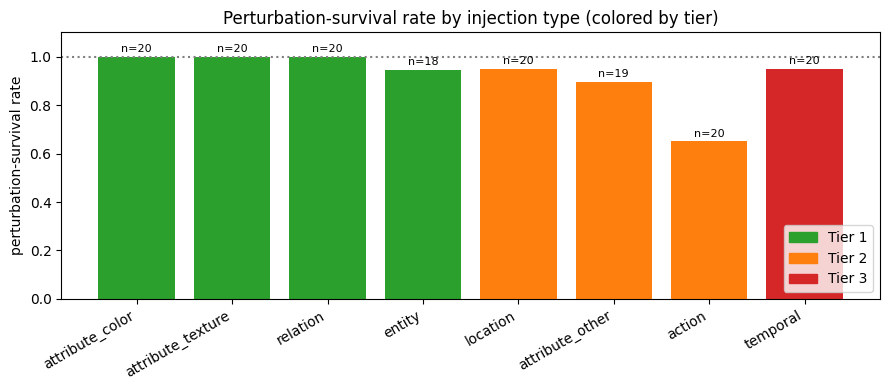

In [52]:
import matplotlib.pyplot as plt

TIERS = {
    "entity": 1, "attribute_color": 1, "attribute_texture": 1, "relation": 1,
    "attribute_other": 2, "location": 2, "action": 2,
    "temporal": 3,
}

df_variant_pipelines = df_inject_pipelines[df_inject_pipelines["variant"] != "original"].copy()
df_variant_pipelines["tier"] = df_variant_pipelines["variant"].map(TIERS)
df_variant_pipelines["survived"] = (
    df_variant_pipelines["perturbation_in_facts"]
    .apply(lambda s: bool(json.loads(s)) if isinstance(s, str) else False)
)

per_tier = (
    df_variant_pipelines
    .groupby(["tier", "variant"])["survived"]
    .agg(survival_rate="mean", n="count")
    .round(3)
)
print("Per-tier / per-variant perturbation-survival rate:")
print(per_tier)

per_tier_reset = (
    per_tier.reset_index()
    .sort_values(["tier", "survival_rate"], ascending=[True, False])
)
tier_colors = {1: "#2ca02c", 2: "#ff7f0e", 3: "#d62728"}
bar_colors = [tier_colors[t] for t in per_tier_reset["tier"]]

plt.figure(figsize=(9, 4))
bars = plt.bar(per_tier_reset["variant"], per_tier_reset["survival_rate"], color=bar_colors)
plt.axhline(1.0, color="grey", linestyle=":", label="100% survival")
for bar, n in zip(bars, per_tier_reset["n"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"n={n}",
        ha="center",
        fontsize=8,
    )
plt.xticks(rotation=30, ha="right")
plt.ylabel("perturbation-survival rate")
plt.ylim(0, 1.1)
plt.title("Perturbation-survival rate by injection type (colored by tier)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in tier_colors.values()]
plt.legend(handles, [f"Tier {t}" for t in tier_colors], loc="lower right")
plt.tight_layout()
plt.show()


Perturbation-survival stratified by fan-out quartile × tier:
                      survival_rate   n
fanout_quartile tier                   
1               1             1.000  20
                2             0.933  15
                3             0.800   5
2               1             1.000  20
                2             0.667  15
                3             1.000   5
3               1             1.000  20
                2             0.800  15
                3             1.000   5
4               1             0.944  18
                2             0.929  14
                3             1.000   5

Per-cell N (small — read as trends, not point estimates):
tier              1   2  3
fanout_quartile           
1                20  15  5
2                20  15  5
3                20  15  5
4                18  14  5


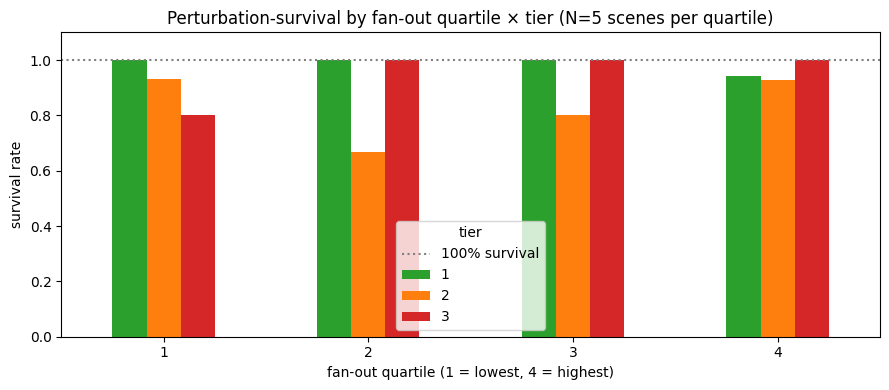

In [53]:
per_q = (
    df_variant_pipelines
    .merge(
        df_inject_variants[["video_id", "scene_id", "variant", "fanout_quartile"]],
        on=["video_id", "scene_id", "variant"], how="left",
    )
    .groupby(["fanout_quartile", "tier"])["survived"]
    .agg(survival_rate="mean", n="count")
    .round(3)
)
print("Perturbation-survival stratified by fan-out quartile × tier:")
print(per_q)

per_q_wide = per_q["survival_rate"].unstack("tier").reindex(index=[1, 2, 3, 4])
per_q_n = per_q["n"].unstack("tier").reindex(index=[1, 2, 3, 4])

print(f"\nPer-cell N (small — read as trends, not point estimates):")
print(per_q_n)

per_q_wide.plot(kind="bar", figsize=(9, 4), color=["#2ca02c", "#ff7f0e", "#d62728"])
plt.axhline(1.0, color="grey", linestyle=":", label="100% survival")
plt.xlabel("fan-out quartile (1 = lowest, 4 = highest)")
plt.ylabel("survival rate")
plt.ylim(0, 1.1)
plt.title("Perturbation-survival by fan-out quartile × tier (N=5 scenes per quartile)")
plt.legend(title="tier")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Perturbation landings (rows = injection type, cols = surviving-fact DSG category):
                   event  entity  relation  attribute  action  global  other
attribute_color       18      20        21         26       4       0      3
attribute_texture     20      16        20         16       2       0      0
entity                18      17        21          8       4       0      0
relation              25      29        32         10       2       1      0
action                19       7         6          9       5       1      0
attribute_other       17       8        10          9       1       2      0
location              21      21        18          8       1       1      0
temporal              30      42        29         14       8       4      1


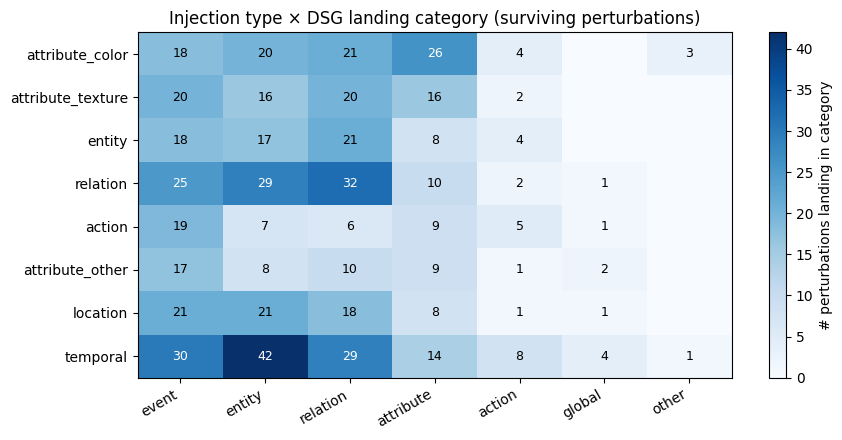

In [54]:
from collections import Counter

landing = {}
for _, row in df_variant_pipelines.iterrows():
    cats = (
        json.loads(row["perturbation_categories"])
        if isinstance(row["perturbation_categories"], str)
        else {}
    )
    landing.setdefault(row["variant"], Counter()).update(cats)

variant_order = sorted(landing, key=lambda v: (TIERS[v], v))
all_cats = sorted(
    {c for cnt in landing.values() for c in cnt},
    key=lambda c: -sum(cnt.get(c, 0) for cnt in landing.values()),
)

matrix = pd.DataFrame(
    [[landing[v].get(c, 0) for c in all_cats] for v in variant_order],
    index=variant_order,
    columns=all_cats,
)
print("Perturbation landings (rows = injection type, cols = surviving-fact DSG category):")
print(matrix)

plt.figure(figsize=(9, 4.5))
im = plt.imshow(matrix.values, cmap="Blues", aspect="auto")
plt.colorbar(im, label="# perturbations landing in category")
plt.xticks(range(len(all_cats)), all_cats, rotation=30, ha="right")
plt.yticks(range(len(variant_order)), variant_order)
_vmax = matrix.values.max() if matrix.values.size else 0
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        v = int(matrix.iat[i, j])
        if v:
            plt.text(
                j, i, str(v),
                ha="center", va="center",
                color=("white" if v > _vmax * 0.5 else "black"),
                fontsize=9,
            )
plt.title("Injection type × DSG landing category (surviving perturbations)")
plt.tight_layout()
plt.show()


In [55]:
n_fail = int(df_inject_variants["inject_failed"].sum())
print(f"Injection failures: {n_fail} / {len(df_inject_variants)} "
      f"({n_fail / len(df_inject_variants):.1%})")

if n_fail:
    print("\nFailure counts by type:")
    print(df_inject_variants[df_inject_variants["inject_failed"]]["variant"].value_counts())

    print("\nFailure examples (up to 2 per failing type):")
    failed = df_inject_variants[df_inject_variants["inject_failed"]].copy()
    failed["tier"] = failed["variant"].map(TIERS)
    for _, ex in failed.groupby("variant").head(2).iterrows():
        print(f"  [{ex['variant']}] {ex['scene_id']}  (retries exhausted — likely no valid substring to perturb)")

print("\nExample successful injections (2 per tier):")
successful = df_inject_variants[~df_inject_variants["inject_failed"]].copy()
successful["tier"] = successful["variant"].map(TIERS)
for tier in sorted(successful["tier"].unique()):
    print(f"\n--- Tier {tier} ---")
    examples = (
        successful[successful["tier"] == tier]
        .groupby("variant", group_keys=False)
        .apply(lambda g: g.head(1))
        .head(2)
    )
    for _, ex in examples.iterrows():
        print(f"  [{ex['variant']}] {ex['scene_id']}")
        print(f"    original:    {ex['original_span']!r}")
        print(f"    replacement: {ex['replacement_span']!r}")
        print(f"    rationale:   {ex['rationale']}")


  .apply(lambda g: g.head(1))

  .apply(lambda g: g.head(1))

  .apply(lambda g: g.head(1))



Injection failures: 3 / 160 (1.9%)

Failure counts by type:
variant
entity             2
attribute_other    1
Name: count, dtype: int64

Failure examples (up to 2 per failing type):
  [entity] scene_018.mp4  (retries exhausted — likely no valid substring to perturb)
  [attribute_other] scene_018.mp4  (retries exhausted — likely no valid substring to perturb)
  [entity] scene_041.mp4  (retries exhausted — likely no valid substring to perturb)

Example successful injections (2 per tier):

--- Tier 1 ---
  [attribute_color] scene_054.mp4
    original:    'river'
    replacement: 'blue river'
    rationale:   Rivers are not typically described by color, making 'blue river' an unusual and potentially misleading description.
  [attribute_texture] scene_054.mp4
    original:    'a river'
    replacement: 'a pool'
    rationale:   Deer are swimming in a pool, not a river.

--- Tier 2 ---
  [action] scene_054.mp4
    original:    'swimming'
    replacement: 'flying'
    rationale:   Deer cannot

### Injection-readiness table

Grounded in the fact-extraction subcategory counts and the FIFA Table 6 VQA
accuracy ranges cited earlier:

| Tier | Injection type | Extract-side sample | FIFA Table 6 VQA accuracy | Expected effect-size behaviour |
| --- | --- | --- | --- | --- |
| 1 | attribute_color   | 266 color facts     | 73–90% (attribute) | Clean drop; primary signal |
| 1 | attribute_texture | 192 texture facts   | 73–90%             | Clean drop; primary signal |
| 1 | entity            | 2516 entities       | 84–90%             | Clean drop; primary signal (via description-string swap) |
| 1 | relation          | 1421 (95.6% spatial)| 71–76% (spatial)   | Clean drop |
| 2 | attribute_other   | ~926 non-c/t facts  | 73–90%             | Clean drop, mixed sub-types |
| 2 | location          | via spatial-relation args | 71–76%       | String-manipulation; monitor whether it lands in `relation - spatial` |
| 2 | action            | 721 (no sub-cat)    | 55–74%             | Noisier; question ~7 words |
| 3 | temporal          | 200 typed facts total (0.30/scene) | 20–68% | Noisy; report as pilot |

**Scope**: measured on **N=20** scenes stratified into 5 per fan-out quartile
(`n_edges` quartiles from `df_dstats`). Perturbation-survival is a necessary
precursor to FIFA score-drop evidence; the score-drop measurement requires
running the Verify Facts section on all 20 × 9 = 180 pipelines and is called
out as follow-up work.


# Verify Facts

In [ ]:
try:
    extractor_llm.delete_model()
    del extractor_llm
except NameError:
    pass

for _name in ("glm_struct", "glm_model", "glm_tokenizer"):
    globals().pop(_name, None)

cleanup_gpu()

if torch.cuda.is_available():
    print(f"allocated: {torch.cuda.memory_allocated() / 1e9:.1f} GB, "
          f"reserved: {torch.cuda.memory_reserved() / 1e9:.1f} GB")


allocated: 0.0 GB, reserved: 0.2 GB


In [ ]:
from transformers import Qwen3VLMoeForConditionalGeneration, AutoProcessor

VQA_MODEL = "Qwen/Qwen3-VL-30B-A3B-Instruct"

vqa_processor = AutoProcessor.from_pretrained(VQA_MODEL)
vqa_model = Qwen3VLMoeForConditionalGeneration.from_pretrained(
    VQA_MODEL, dtype="auto", device_map="auto"
)

# Same frame-sampling contract as the description stage: we hand over pre-sampled
# frames, so the processor must not resample, and it needs the real metadata or the
# per-frame timestamps written into the prompt will be wrong.
vqa_vp = vqa_processor.video_processor
vqa_vp.do_sample_frames = False
vqa_vp.video_metadata = [metadata]


def answer(question: str, video_frames=None, max_new_tokens: int = 128) -> str:
    video_frames = frames if video_frames is None else video_frames
    messages = [{
        "role": "user",
        "content": [
            {"type": "video", "video": video_frames},
            {"type": "text", "text": question},
        ],
    }]
    text = vqa_processor.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = vqa_processor(
        text=text, videos=[video_frames], padding=True, return_tensors="pt"
    ).to(vqa_model.device)
    out = vqa_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return vqa_processor.tokenizer.decode(
        out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip()


print(answer("Is there a bottle?"))


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.66k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/882 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Yes, there are three bottles in the video.


In [ ]:
_AFFIRM = {"yes", "yeah", "yep", "correct", "true", "affirmative"}
_DENY = {"no", "nope", "not", "false", "incorrect", "none", "never"}


def fifa_score(ans: str) -> float:
    """Verbatim reproduction of eval_video2text.py:63."""
    return float("yes" in ans.lower())


def strict_score(ans: str):
    """Return 1.0 / 0.0, or None when the answer is genuinely ambiguous.

    eval_video2text.py:63 does a bare substring test, so "yesterday" scores 1.0 and
    "There is no dog, yes I am sure" scores 1.0. Leading token wins here instead.
    """
    text = re.sub(r"[^a-z' ]+", " ", ans.lower()).strip()
    tokens = text.split()
    if not tokens:
        return None
    if tokens[0] in _AFFIRM:
        return 1.0
    if tokens[0] in _DENY:
        return 0.0
    if re.search(r"\bthere (is|are) no\b|\b(does|do|did) not\b|\bis not\b", text):
        return 0.0
    if re.search(r"\byes\b", text):
        return 1.0
    if re.search(r"\bno\b", text):
        return 0.0
    return None


def propagate_reference(scores, deps):
    """Single pass in dict order, reproducing eval_video2text.py:68-84.

    Order-dependent by construction: a parent zeroed after its child was visited
    does not zero that child. Kept so the reference number is reportable.
    """
    scores, validity = dict(scores), {}
    for did, parents in deps.items():
        if did not in scores:
            continue
        if any(scores.get(p) == 0 for p in parents):
            scores[did], validity[did] = 0.0, False
        else:
            validity[did] = True
    return scores, validity


def propagate_transitive(scores, deps):
    """Iterate to a fixpoint so zeroing propagates down the whole chain."""
    scores, validity = dict(scores), {d: True for d in deps if d in scores}
    changed = True
    while changed:
        changed = False
        for did, parents in deps.items():
            if did not in scores or scores[did] == 0:
                continue
            if any(scores.get(p) == 0 for p in parents):
                scores[did], validity[did] = 0.0, False
                changed = True
    return scores, validity


In [ ]:
scored = [r for r in stsdg if r["question"]]
assert scored, "no questions to score; re-run the question generation cell"

answers = {r["id"]: answer(r["question"]) for r in scored}

raw_fifa = {i: fifa_score(a) for i, a in answers.items()}
raw_strict = {i: strict_score(a) for i, a in answers.items()}

ambiguous = [i for i, s in raw_strict.items() if s is None]
raw_strict_filled = {i: (0.0 if s is None else s) for i, s in raw_strict.items()}

ref_scores, ref_validity = propagate_reference(raw_fifa, deps_clean)
tr_scores, tr_validity = propagate_transitive(raw_strict_filled, deps_clean)


def mean(d):
    return sum(d.values()) / len(d) if d else float("nan")


print(f"{'id':>3}  {'score':>5}  {'valid':>5}  question / answer")
for r in scored:
    i = r["id"]
    print(f"{i:>3}  {tr_scores[i]:>5.0f}  {str(tr_validity.get(i, True)):>5}  {r['question']}")
    print(f"       -> {answers[i][:90]}")

print()
print(f"ambiguous answers        : {len(ambiguous)} {ambiguous}")
print(f"fifa vs strict disagree  : "
      f"{sorted(i for i in raw_fifa if raw_fifa[i] != raw_strict_filled[i])}")
print()
print(f"no-dependency  (reference metric) : {mean(raw_fifa):.3f}")
print(f"single-pass    (reference metric) : {mean(ref_scores):.3f}")
print(f"transitive     (corrected)        : {mean(tr_scores):.3f}")
print(f"single-pass vs transitive differ  : "
      f"{sorted(i for i in ref_scores if ref_scores[i] != tr_scores[i])}")

faithfulness = {
    "n_facts": len(scored),
    "n_ambiguous": len(ambiguous),
    "average_score_without_dep": mean(raw_fifa),
    "average_score_reference": mean(ref_scores),
    "average_score_transitive": mean(tr_scores),
    "answers": answers,
    "scores": tr_scores,
    "validity": tr_validity,
}


 id  score  valid  question / answer
  1      1   True  Is there a water bottle?
       -> Yes
  2      1   True  Are there three water bottles?
       -> Yes, there are three water bottles in the video.
  3      1   True  Are the water bottles blue?
       -> Yes, the water bottles are blue.
  4      1   True  Are there caps on the water bottles?
       -> Yes
  5      1   True  Are the water bottles partially filled with water?
       -> Yes
  6      1   True  Is there a white surface?
       -> Yes
  7      1   True  Is there a wall?
       -> Yes
  8      1   True  Is the wall plain and light-colored?
       -> Yes
  9      1   True  Is there a person's hand?
       -> Yes
 10      1   True  Is there a sleeve on the person's hand?
       -> Yes
 11      1   True  Is the sleeve red?
       -> Yes
 12      1   True  Are the water bottles on the white surface?
       -> Yes
 13      0   True  Are the water bottles against the wall?
       -> No, the water bottles are not against the w

In [ ]:
def score_record(rec, video_frames=None):
    scored = [f for f in rec["facts"] if f["id"] in rec["questions"]]
    if not scored:
        return None
    answers = {f["id"]: answer(rec["questions"][f["id"]], video_frames) for f in scored}

    strict_raw = {i: strict_score(a) for i, a in answers.items()}
    filled = {i: (0.0 if s is None else s) for i, s in strict_raw.items()}
    transitive, validity = propagate_transitive(filled, rec["deps"])
    reference, _ = propagate_reference(
        {i: fifa_score(a) for i, a in answers.items()}, rec["deps"]
    )
    return {
        "n_facts": len(scored),
        "n_ambiguous": sum(1 for s in strict_raw.values() if s is None),
        "average_score_without_dep": sum(filled.values()) / len(filled),
        "average_score_reference": sum(reference.values()) / len(reference),
        "average_score_transitive": sum(transitive.values()) / len(transitive),
        "answers": answers,
        "scores": transitive,
        "validity": validity,
    }


variant_results = {}
for _name, _rec in pipelines.items():
    variant_results[_name] = score_record(_rec)
    print(f"scored {_name}")

_base = variant_results["original"]
print()
print(f"{'variant':10s} {'facts':>5} {'score':>6} {'delta':>7} {'ref':>6} "
      f"{'refdelta':>8}  perturbation reached facts")
print(f"{'original':10s} {_base['n_facts']:>5} "
      f"{_base['average_score_transitive']:>6.3f} {'':>7} "
      f"{_base['average_score_reference']:>6.3f} {'':>8}")

_detected = 0
for _name, _r in variant_results.items():
    if _name == "original" or _r is None:
        continue
    _d = _r["average_score_transitive"] - _base["average_score_transitive"]
    _rd = _r["average_score_reference"] - _base["average_score_reference"]
    _reached = pipelines[_name]["perturbation_in_facts"]
    _detected += _d < 0
    print(f"{_name:10s} {_r['n_facts']:>5} {_r['average_score_transitive']:>6.3f} "
          f"{_d:>+7.3f} {_r['average_score_reference']:>6.3f} {_rd:>+8.3f}  "
          f"{_reached if _reached else 'NOT EXTRACTED'}")

_n = len(variant_results) - 1
print(f"\nFIFA scored {_detected}/{_n} corrupted descriptions below the original")
print("Variants whose injected error never reached the fact set are untestable by "
      "FIFA; count them separately from genuine misses.")


scored original
scored entity
scored attribute
scored location
scored action
scored relation
scored temporal

variant    facts  score   delta    ref refdelta  perturbation reached facts
original      27  0.852          0.852         
entity        28  0.393  -0.459  0.393   -0.459  NOT EXTRACTED
attribute     22  0.727  -0.125  0.727   -0.125  [1, 2, 3, 4, 5, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
location      18  1.000  +0.148  1.000   +0.148  [6, 7, 11, 12]
action        23  0.739  -0.113  0.739   -0.113  [1, 2, 3, 4, 5, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23]
relation      33  0.818  -0.034  0.818   -0.034  [1, 2, 3, 4, 5, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 31, 32, 33]
temporal      20  0.800  -0.052  0.800   -0.052  [1, 2, 5, 11, 12, 13, 14, 15, 16, 18, 19]

FIFA scored 5/6 corrupted descriptions below the original
Variants whose injected error never reached the fact set are untestable by FIFA; count them separately from genuine misses.


In [ ]:
for _name in ("vqa_model", "vqa_processor", "vqa_vp", "answer"):
    try:
        del globals()[_name]
    except KeyError:
        pass

cleanup_gpu()

if torch.cuda.is_available():
    print(f"allocated: {torch.cuda.memory_allocated() / 1e9:.1f} GB, "
          f"reserved: {torch.cuda.memory_reserved() / 1e9:.1f} GB")

allocated: 0.0 GB, reserved: 0.2 GB
